In [2]:
!pip install wquantiles
!pip install wcorr
!pip install catboost -q
!pip install shap lime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 556.5 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=4a8f22234a06373c17e9f1911fd1d1040254a0657b1498cb278d30974265ece8
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import statsmodels.api as sm
import warnings
import xgboost as xgb

from catboost import CatBoostRegressor
from scipy.stats import randint, uniform
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LassoCV, LinearRegression, LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, mean_squared_error, roc_curve,
                             precision_score, recall_score, roc_auc_score)
from sklearn.metrics import r2_score as R2, mean_absolute_error as MAE, root_mean_squared_error as RMSE
from sklearn.model_selection import (GridSearchCV, HalvingRandomSearchCV, RandomizedSearchCV,
                                     cross_val_score, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
import lightgbm as lgb

# 1. Построение прогностической модели

## 1.1. Обснование методологии

Для дальнейшего использования в рамках создаваемых моделей данных, собранных и предобработанных на этапе разведочного анализа, загрузим получившийся датасет:

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_excel('/content/processed_df.xlsx')

In [6]:
df.head()

,Family_Wealth,Home_Educaional_Resources,Home_Cultural_Resources,Mothers_Education,Fathers_Education,Highest_Parental_Education,Parents_emotional_support,Parents_learning_support,Teacher_support,Teacher_engagement,School_cooperation,School_competitiveness,Discriminating_climate,Sex,Immigration_Status,Grade_Repetition,Learning_time_per_week,School_attitude,Persistence,Competitiveness,Neuroticism,Resilence,Motivation,Agreeableness,Сognitive_abilities,Weights,Grades
0,-0.273077,-0.343569,-0.271062,"ISCED 3A, ISCED 4",ISCED 5B,ISCED 5B,Strongly disagree,Strongly disagree,Strongly agree,Strongly disagree,-0.907023,0.818260,0.774063,Male,Native,Did not repeat a grade,1575,-1.019794,0.490764,-0.708217,-1.979491,0.251532,-2.232942,0.997193,-0.288237,33.68177,4627.390333
1,1.744554,0.916468,1.027900,"ISCED 5A, 6",ISCED 5B,"ISCED 5A, 6",Agree,Agree,Agree,Agree,0.622971,-0.062033,0.006312,Male,Native,Did not repeat a grade,1575,-0.268408,0.239738,-0.157990,-0.050583,-0.171202,0.712579,0.053661,0.067309,33.68177,4167.809667
2,0.939412,-1.532721,2.838671,"ISCED 5A, 6","ISCED 5A, 6","ISCED 5A, 6",Agree,Agree,Disagree,Disagree,-0.184689,0.052851,-0.082513,Female,Native,Did not repeat a grade,1575,-0.767082,0.239738,-0.221939,-0.050583,-1.031889,-1.179932,-1.596094,0.172182,33.68177,3517.277667
3,-1.319868,-0.526490,-0.130827,ISCED 5B,ISCED 5B,ISCED 5B,Agree,Agree,Disagree,Disagree,0.622971,-0.542629,-1.152584,Female,Native,Did not repeat a grade,1575,-0.268408,-0.919860,-0.708217,-0.604661,-1.070633,-2.232942,-0.262506,-0.901150,33.68177,3335.927000
4,-0.132970,-1.532721,1.027900,ISCED 5B,ISCED 5B,ISCED 5B,Agree,Strongly agree,Agree,Disagree,0.622971,-0.062033,0.006312,Female,Native,Did not repeat a grade,945,-0.260652,0.239738,2.143837,-0.050583,-0.171202,-1.800702,0.053661,-0.529703,33.68177,4003.476667


В настоящий момент в датасете присутствуют категориальные переменные, которые наобходимо закодировать. Проведем кодирование категориальных переменных в соответствии со следующей логикой:

* Для переменных **"Mothers_Education"**, **"Fathers_Education"**,**"Highest_Parental_Education"** будем использовать иерархическую классификацию, согласно которой каждой ступени образования будет присвоен порядковый номер, соответствующий очередности ее получения.

* Значения для переменных **"Parents_emotional_support"**, **"Parents_learning_support"**, **"Teacher_support"** и **"Teacher_engagement"** был использован диапазон значений от -2 до 2, где значение "-2" означало высшую степень несогласия, а "2" - высшую степень согласия с утверждением о факторе.

* Переменная **"Sex"** была бинаризирована: для обучающихся женского пола использовалось значение "1", для обучающихся мужского пола - "0"

* Значения переменной **"Grade_Repetition"** тоже были переведены в бинарную форму. Для обозначения школьников, остававшихся на второй год, использовалось значение "1", а для тех, кто не был вынужден проходить дисциплины повторно, - значение "0"


In [7]:
edu_trans = {'ISCED 1': 1, 'ISCED 2': 2, 'ISCED 3B, C': 3, 'ISCED 3A, ISCED 4': 4, 'ISCED 5B': 5, 'ISCED 5A, 6': 6}
quest_trans = {'Disagree': -2, 'Strongly disagree': -1, 'Agree': 1, 'Strongly agree': 2}
sex_trans = {'Female': 1, 'Male': 0}
rep_trans = {'Did not repeat a  grade': 0, 'Repeated a  grade': 1}

df['Mothers_Education'] = df['Mothers_Education'].map(edu_trans)
df['Fathers_Education'] = df['Fathers_Education'].map(edu_trans)
df['Highest_Parental_Education'] = df['Highest_Parental_Education'].map(edu_trans)
df['Sex'] = df['Sex'].map(sex_trans)
df['Parents_emotional_support'] = df['Parents_emotional_support'].map(quest_trans)
df['Parents_learning_support'] = df['Parents_learning_support'].map(quest_trans)
df['Teacher_support'] = df['Teacher_support'].map(quest_trans)
df['Teacher_engagement'] = df['Teacher_engagement'].map(quest_trans)
df['Grade_Repetition'] = df['Grade_Repetition'].map(rep_trans)

После преобразования вышеупомянутых признаков остается только одна непреобразованная категориальная переменная "Immigration_Status", отражающая иммиграционный статус. В отношении нее принято решение о создании дамми-переменных с исключением первого значения признака при создании столбцов для предотвращения дупликации информации и необоснованного расширения признакового поля:

In [8]:
imm_dummies = pd.get_dummies(df['Immigration_Status'], prefix='Immigration', drop_first=True).astype('int')
df = pd.concat([df, imm_dummies], axis=1)
del df['Immigration_Status']

Убедимся, что после преобразования независимых переменных мы получили датасет, содержащий исключительно числовые значения:

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14604 entries, 0 to 14603
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Family_Wealth                  14604 non-null  float64
 1   Home_Educaional_Resources      14604 non-null  float64
 2   Home_Cultural_Resources        14604 non-null  float64
 3   Mothers_Education              14604 non-null  int64  
 4   Fathers_Education              14604 non-null  int64  
 5   Highest_Parental_Education     14604 non-null  int64  
 6   Parents_emotional_support      14604 non-null  int64  
 7   Parents_learning_support       14604 non-null  int64  
 8   Teacher_support                14604 non-null  int64  
 9   Teacher_engagement             14604 non-null  int64  
 10  School_cooperation             14604 non-null  float64
 11  School_competitiveness         14604 non-null  float64
 12  Discriminating_climate         14604 non-null 

Стоит обратить внимание, что в настоящий момент целевая переменная представлена в виде непрерывной величины. Учитывая тот факт, что в ходе исследования предполагается построение прогностической модели для выявления обучающихся, входящих в группу академического риска, нам необходимо создать дополнительную бинарную таргет-переменную. Будущая переменная должна отражать общее понимание академического успеха и соответствовать общей методологии исследования PISA для репрезентативности результатов.

Международная программа по оценке образовательных достижений учащихся (PISA) при реализации исследования использует содержательно интерпретируемую систему уровней грамотности, содержащую 6 ступеней. Каждый уровень характеризуется определенным диапазоном баллов и соответствующим описанием выполняемых когнитивных операций. Для нашего исследования наиболее важным из всех уровней является второй, определяемый PISA как порог базовой (функциональной) грамотности. Этот же критерий используется научно-исследовательским сообществом для детекции обучающихся, входящих в группу академического риска (Agasisti & Zoido, 2018; Schleicher, 2019).

Согласно таблице уровней граммотности и соотвествующим балльным диапазонам, опубликованным в техническом описании шкал и пороговых значений PISA, для преодоления порога базовой грамотности ученик в среднем должен набрать минимум 420.1 балл за вопрос в рамках математического тестирования, 407.5 баллов за один вопрос в рамках тестирования читательских навыков и 409.5 баллов за один вопрос в тестировании естественно-научных знаний. На основании этих значений мы создаем формулу для расчета порогового значения успешно пройденного тестирования:

$$
\text{Threshold} = \frac{\min_{\text{математика}} \times n_{\text{вопросов}} \;+\; \min_{\text{чтение}} \times n_{\text{вопросов}} \;+\; \min_{\text{естествознание}} \times n_{\text{вопросов}}}{3} $$

Подставив минимальные значения баллов и количество вопросов, получим:

$$
\text{Threshold} = \frac{420.1 \times 10 + 407.5 \times 10 + 409.5 \times 10}{3}
= \frac{4201 + 4075 + 4095}{3}
= \frac{12371}{3}
\approx 4123.7
$$

Для консервативности и простоты округлим получившееся значение до 4125 баллов. Таким образом, обучающиеся, набравшие менее 4125 баллов по композитному показателю "Grades", будут классифицированы как "находящиеся в зоне академического риска" (**'Academic_risk'** = 1), а все остальные как "не находящиеся в зоне риска" (**'Academic_risk'** = 0):

In [10]:
df['Academic_risk'] = (df['Grades'] < 4125).astype('int')

Главной задачей реализуемого исследования является не только проведение анализа влияния социально-экономических и личностных характеристик обучающихся на образовательный успех, но и построение прогностической модели для детекции школьников с риском неуспеваемости. В связи с этим текущее исследование будет состоять из двух параллельных, но взаимосвязанных линий моделирования:

1. *Анализ влияния социально-экономических факторов и персональных характеристик на учебную успеваемость*

Для этого направления будет использоваться непрерывная переменная "Grades" и регресионные модели машинного обучения, позволяющие количественно оценить степень и направление влияния исследуемых независимых переменных. В рамках исследования планируется построение моделей Linear Regression, Lasso Regression, Decision Tree, Random Forest, CatBoost. Основными метриками для оценки качества построенных моделей будут выступать среднеквадратичная ошибка ($RMSE$), средняя абсолютная ошибка ($MAE$) и коэффициент детерминации ($R^2$)

2. *Выявление студентов, находящихся в группе академического риска*

В рамках этого направления в качестве целевой переменной будет рассматриваться бинарная переменная **"Academic_risk"**, а для достижения поставленной цели будут использоваться модели машинного обучения, решающие задачу классификации - Logistic Regression, Desicion Tree, Random Forest, XGBoost, CatBoost. Оценка качества указанных моделей будет производиться при расчете таких метрик качества, как $Recall$, $Precision$ и $F1-Score$.

Два направления моделирования не являются изолированными - совместно они образуют единую аналитическую картину. Результаты регрессионного анализа помогут ответить на вопрос "Как и насколько сильно факторы влияют на успеваемость?", в то время как результаты моделей классификаци помогут ответить на вопрос "Можно ли на основе этих факторов с высокой точностью выявить учащихся, которым нужна помощь?".

Финальным этапом исследования станет сравнительный XAI-анализ с применением метода SHAP к лучшим моделям обоих направлений. Выбранная методология позволит сопоставить глобальную важность признаков в двух задачах, выявить факторы, значимые для обеих формулировок, провести детальное изучение конкретных примеров с помощью локальных объяснений и выявить нелинейные связи между признаками.

Перед переходом более глобальным эмпирическим задачам, подготовим два типа датасетов, которые будут далее использоваться при построении моделей:

* *Датасет для линейных моделей*

В этом датасете будет использоваться сокращенное признаковое пространство для решения проблемы мультиколлинеарности и получения искаженных результатов. В частности он будет содержать признаки из итогового датафрейма, за исключением признаков **"Mothers_Education"**, **"Fathers_Education"**, **"Parents_emotional_support"**.

* *Датасет для древовидных моделей и моделей градиентного бустинга*

Этот датасет будет содержать полноценное признаковое пространство, поскольку модели, для которых он будет использоваться, являются устойчивыми к проблеме мультиколлинеарности и могут давать менее точнее ответы при неполном представлении признаков.


In [11]:
lin_df = df.copy().drop(columns=['Mothers_Education', 'Fathers_Education', 'Parents_emotional_support', 'Weights', 'Grades', 'Academic_risk'])
full_df = df.copy().drop(columns=[ 'Weights', 'Grades', 'Academic_risk'])

Отдельно будут рассмотрены целевые переменные в их бинарной и непрервыной числовой форме:

In [12]:
Y_reg = df['Grades'].copy()
Y_cl = df['Academic_risk'].copy()

Для корректности построения моделей и репрезентативности полученных результатов будем использовать переменную, отражающую вес каждого обучающегося в выборке:

In [13]:
W = df['Weights']

После определения датасетов с независимыми признаками, целевых переменных в двух форматах и переменной весов можем произвести разделение на контрольную и тестовую выборки.

Учитывая тот факт, что в рамках проводимого исследования нами создано два разных датасета, для линейных моделей и древовидных/моделей градиентного бустинга, а также поставлено две задачи, регрессии и классификации, необходимо сформировать четыре набора данных для обучения и тестирования. При этом базовое разбиение на выборки должно быть единым, поскольку это критически важно для последующей интерпретации. Единая стратификация обеспечит обучение и тестирование моделей на одних и тех же наблюдениях, что сделает сравнение результатов моделей корректным. Кроме того, когда мы начнем строить интерпретационные SHAP-графики для конкретного ученика, мы будем уверены, что в рамках всех реализованных моделей он попал в одну и ту же выборку.

Произведем базовое разбиение на обучающую и тестовую выборку с учетом стратификации по переменной **"Academic_risk"**:

In [14]:
indexes = np.arange(len(lin_df))

train_idx, test_idx = train_test_split(indexes, test_size=0.2, stratify=df['Academic_risk'], random_state=42)

На основании присвоенных контрольной и тестовой выборкам индексов произведем создание выборок для двух видов датасетов и двух типов моделей:

In [15]:
# Независимые переменные для линейных моделей
X_train_lin = lin_df.iloc[train_idx].copy()
X_test_lin = lin_df.iloc[test_idx].copy()

# Независимые переменные для древовидных моделей/моделей градиентного бустинга
X_train_full = full_df.iloc[train_idx].copy()
X_test_full = full_df.iloc[test_idx].copy()

# Целевые переменные для линейных моделей
y_train_reg = Y_reg.iloc[train_idx].copy()
y_test_reg = Y_reg.iloc[test_idx].copy()

# Целевые переменные для древовидных моделей/моделей градиентного бустинга
y_train_cl = Y_cl.iloc[train_idx].copy()
y_test_cl = Y_cl.iloc[test_idx].copy()

# Веса для обучающей и тестовой выборки
w_train = W.iloc[train_idx].copy()
w_test = W.iloc[test_idx].copy()

Мы произвели разделение на выборки, теперь нам необходимо привести данные признаков к стандартизированному виду. Преобразование приведет значения переменных к единому масштабу, что предотвратит появление проблемы доминации признаков с высокими значениями над более низкими и ускорит обучение моделей. Стоит отметить, что мы проводим стандартизацию исключительно для выборок для линейных моделей, поскольку древовидные модели и модели градиентного бустинга  не чувствительны к масштабу:

In [16]:
cols_for_standartization = ['Family_Wealth', 'Home_Educaional_Resources', 'Home_Cultural_Resources',
                            'Parents_learning_support', 'Teacher_support', 'Teacher_engagement',
                            'School_cooperation', 'School_competitiveness', 'Discriminating_climate',
                            'Learning_time_per_week', 'School_attitude', 'Persistence', 'Competitiveness',
                            'Neuroticism', 'Resilence', 'Motivation', 'Agreeableness', 'Сognitive_abilities']

In [17]:
scaler = StandardScaler()
X_train_lin[cols_for_standartization] = scaler.fit_transform(X_train_lin[cols_for_standartization])
X_test_lin[cols_for_standartization] = scaler.transform(X_test_lin[cols_for_standartization])

После проведенных преобразований наши данные полностью готовы для построения моделей машинного обучения по выбранным направлениям

# 2. Построение моделей машинного обучения

## 2.1. Построение регрессионных моделей для анализа влияния факторов на учебную успеваемость

### 2.1.1. Создание кастомных функций по расчету взвешенных метрик качества

Ввиду того что мы используем модели с указанием веса каждого студента,  корректным подходом в оценке качества моделей будет использование взвешенных метрик: взвешенного $RMSE$, взвешенной $MAE$ и взвешенного $R^2$. Если для коэффициента детерминации ($R^2$) поддержка весов в функции реализована напрямую, то в случае с средней абсолютной ошибкой ($MAE$) и корнем среднеквадратической ошибки ($RMSE$) такой опции нет. В связи с этим возникает необходимость создания собственных функций по расчету взвешенных метрик.

Рассмотрим формулу расчета стандартной средней абсолютной ошибки:
$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| = \frac{1}{n} \sum_{i=1}^{n} |d_i|
$$

Для взвешенной $MAE$ производится замена обычного среднего из стандартной формулы на взвешенное среднее:

$$
\text{WMAE} = \frac{1}{W} \sum_{i=1}^{n} w_i \cdot |y_i - \hat{y}_i| = \frac{1}{\sum_{j=1}^{n} w_j} \sum_{i=1}^{n} w_i |d_i|
$$

Таким образом, мы получаем следующий переход от стандартной средней абсолютной ошибки к взвешенной:

$$
{\frac{1}{n} \sum_{i=1}^{n} |d_i| \;\rightarrow\; \frac{1}{\sum w_i} \sum_{i=1}^{n} w_i |d_i|}
$$

, где $y_i$ - фактическое (истинное) значение для $i$-го наблюдения

 $\hat{y}_i$ - предсказанное моделью значение для $i$-го наблюдения

 $n$ - количество наблюдений в выборке

 $w_i$ - вес $i$-го наблюдения

 $W = \sum_{i=1}^{n} w_i$ - сумма всех весов

 $d_i = y_i - \hat{y}_i$ - Остаток (ошибка) для $i$-го наблюдения


 Напишем собственную функции для расчета взвешенного показателя $MAE$ в соответствии с формулой выше:


In [115]:
def weighted_mae(y_true, y_pred, weights):
    weights_norm = weights * (len(weights) / weights.sum())
    return np.average(np.abs(y_true - y_pred), weights=weights_norm)

Для стандартного корня из среднеквадратической ошибки ($RMSE$) расчет производится по следующей формуле:

$$
\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} d_i^2}
$$

Для взвешенного показателя производится аналогичная $MAE$ замена среднего арифметического на взвешенное среднее, вследствие чего формула приобретает следующий вид:

$$
\text{WRMSE} = \sqrt{\frac{1}{W} \sum_{i=1}^{n} w_i \cdot (y_i - \hat{y}_i)^2} = \sqrt{\frac{1}{\sum_{j=1}^{n} w_j} \sum_{i=1}^{n} w_i d_i^2}
$$

Таким образом, мы получаем переход от стандартного корня среднеквадратической ошибки к взвешенному:

$$
{\sqrt{\frac{1}{n} \sum_{i=1}^{n} d_i^2} \;\rightarrow\; \sqrt{\frac{1}{\sum w_i} \sum_{i=1}^{n} w_i d_i^2}}
$$

, где $y_i$ - фактическое (истинное) значение для $i$-го наблюдения

 $\hat{y}_i$ - предсказанное моделью значение для $i$-го наблюдения

 $n$ - количество наблюдений в выборке

 $w_i$ - вес $i$-го наблюдения

 $W = \sum_{i=1}^{n} w_i$ - сумма всех весов

 $d_i = y_i - \hat{y}_i$ - Остаток (ошибка) для $i$-го наблюдения

 Создадим собственную функции для расчета взвешеннй метрики $RMSE$ в соответствии с формулой выше:


In [116]:
def weighted_rmse(y_true, y_pred, weights):
    weights_norm = weights * (len(weights) / weights.sum())
    return np.sqrt(np.average((y_true - y_pred)**2, weights=weights_norm))

### 2.1.2. Реализация и оценка качества модели Linear Regression (WLS)

Модель линейной регрессии использовалась в качестве базовой модели для решения задачи регрессии и ответа на вопрос о влиятельности социально-экономических факторов и личностных характеристик обучающегося на его академическую успеваемость. Важно отметить, что при построении данного вида модели используется ее взвешенный вариант, учитывающий веса респондентов школьников, для получения репрезентативных оценок. Результаты этой модели используются как эталон, с которым сравниваются последующие, более сложные модели.

In [117]:
X_train_lin_w_const = sm.add_constant(X_train_lin)
X_test_lin_w_const = sm.add_constant(X_test_lin)

wls = sm.WLS(y_train_reg, X_train_lin_w_const, weights=w_train)
wls = wls.fit()

y_pred_train_wls = wls.predict(X_train_lin_w_const)
y_pred_test_wls = wls.predict(X_test_lin_w_const)


print(f'Взвешенный RMSE для обучающей выборки равен {weighted_rmse(y_train_reg, y_pred_train_wls, w_train)}')
print(f'Взвешенный RMSE для тестовой выборки равен {weighted_rmse(y_test_reg,  y_pred_test_wls, w_test)}')
print()
print(f'Взвешеная MAE для обучающей выборки равна {weighted_mae(y_train_reg, y_pred_train_wls, w_train)}')
print(f'Взвешеная MAE для тестовой выборки равна {weighted_mae(y_test_reg,  y_pred_test_wls, w_test)}')
print()
print(f'Взвешенный R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_wls, sample_weight=w_train)}')
print(f'Взвешенный R^2 для тестовой выборки равен {R2(y_test_reg,  y_pred_test_wls, sample_weight=w_test)}')
print()
print(f'RMSE для обучающей выборки равен {RMSE(y_train_reg, y_pred_train_wls)}')
print(f'RMSE для тестовой выборки равен {RMSE(y_test_reg, y_pred_test_wls)}')
print()
print(f'MAE для обучающей выборки равна {MAE(y_train_reg, y_pred_train_wls)}')
print(f'MAE для тестовой выборки равна {MAE(y_test_reg, y_pred_test_wls)}')
print()
print(f'R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_wls)}')
print(f'R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_wls)}')

Взвешенный RMSE для обучающей выборки равен 645.0490068601192
Взвешенный RMSE для тестовой выборки равен 648.5131211598683

Взвешеная MAE для обучающей выборки равна 511.3356148492315
Взвешеная MAE для тестовой выборки равна 507.92882661795164

Взвешенный R^2 для обучающей выборки равен 0.3269880924752717
Взвешенный R^2 для тестовой выборки равен 0.31363374830241897

RMSE для обучающей выборки равен 652.6498255551031
RMSE для тестовой выборки равен 657.1855985555055

MAE для обучающей выборки равна 518.5861878543857
MAE для тестовой выборки равна 516.5454685717594

R^2 для обучающей выборки равен 0.3047046554416699
R^2 для тестовой выборки равен 0.29379971726171894


При построении прогноза на тестовых данных взвешенная линейная регрессия с учетом весов респондентов-школьников продемонстрировала коэффициент детерминации ($R^2$) равный 0.293, что означает, что модель объясняет около 29% дисперсии целевой переменной результатов тестирования. Среднеквадратичная ошибка ($RMSE$) составила 657.19 баллов, а средняя абсолютная ошибка ($MAE$) – 516.55 баллов, что является ожидаемым базовым уровнем для линейной модели, построенной на социально-образовательных данных.

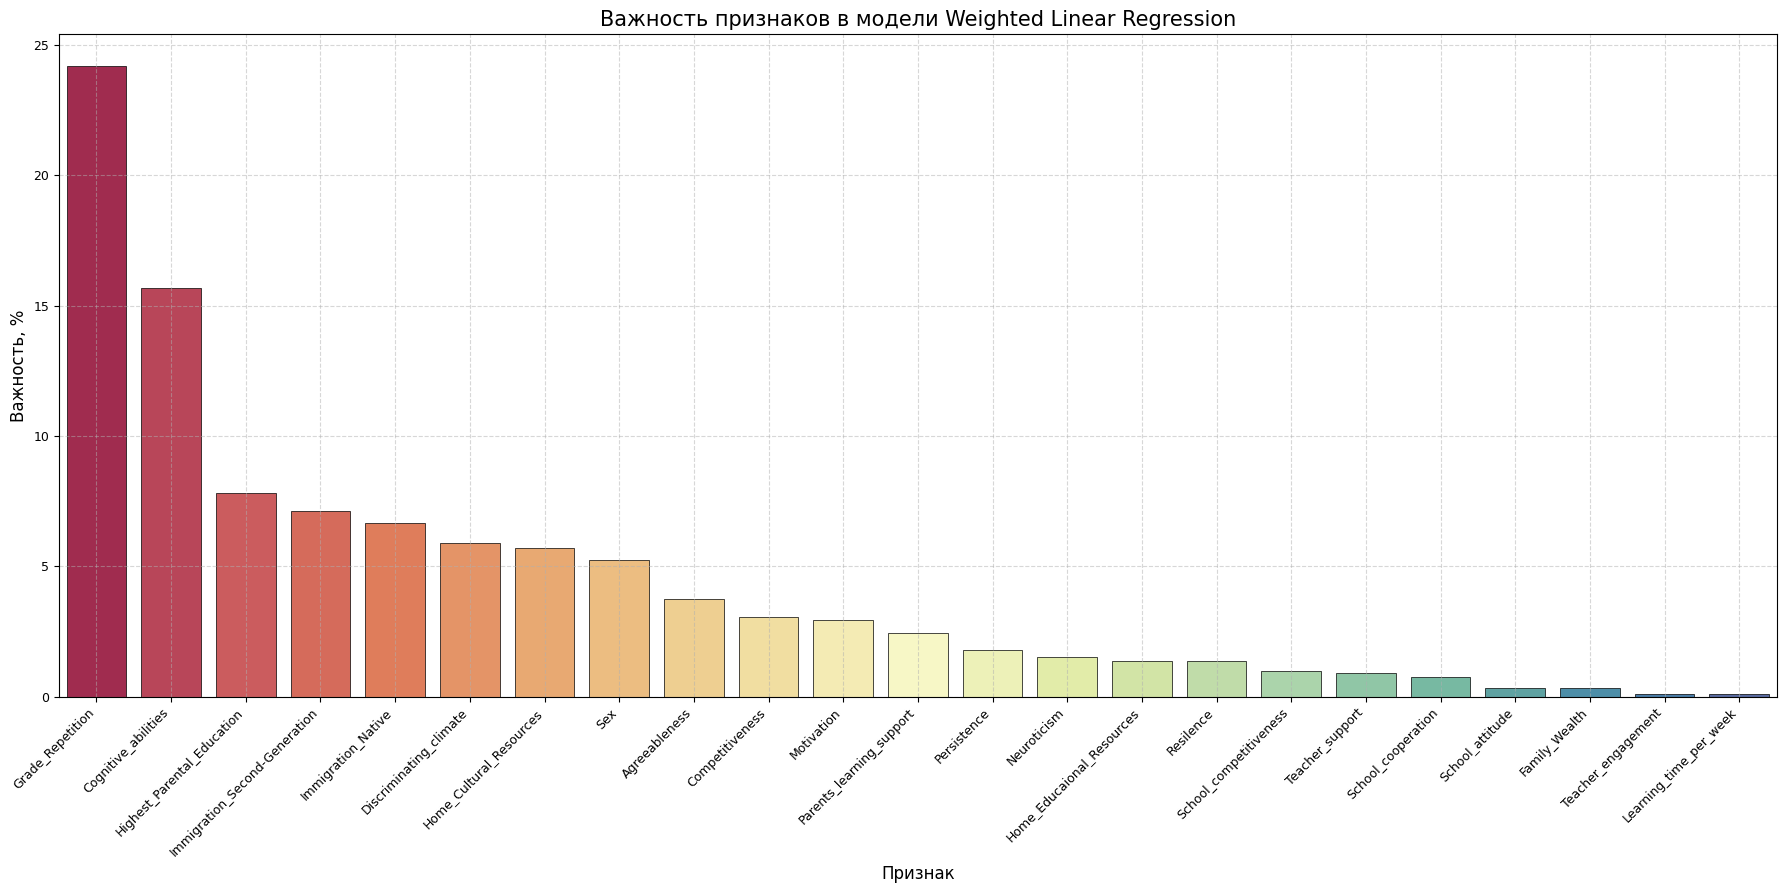

In [118]:
features = list(X_train_lin.columns)
coef_table = pd.DataFrame({'Feature': features, 'Coefficient': wls.params[1:],
                          'Absolute_value': np.abs(wls.params[1:]), 'Importance': 100 * np.abs(wls.params[1:]) / np.sum(np.abs(wls.params[1:]))})
coef_table = coef_table.sort_values('Importance', ascending=False)

plt.figure(figsize=(18, 9))
sns.barplot(x='Feature', y='Importance', data=coef_table, palette='Spectral', edgecolor='black', linewidth=0.5)
plt.title('Важность признаков в модели Weighted Linear Regression', fontsize=15)
plt.xlabel('Признак', fontsize=12)
plt.ylabel('Важность, %', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [119]:
print("Топ наиболее важных признаков:")
coef_table.reset_index(drop=True)

Топ наиболее важных признаков:


,Feature,Coefficient,Absolute_value,Importance
0,Grade_Repetition,-471.664609,471.664609,24.202244
1,Сognitive_abilities,305.416691,305.416691,15.671664
2,Highest_Parental_Education,152.116656,152.116656,7.805471
3,Immigration_Second-Generation,138.898298,138.898298,7.127205
4,Immigration_Native,129.974011,129.974011,6.669279
5,Discriminating_climate,-114.760297,114.760297,5.888626
6,Home_Cultural_Resources,110.810296,110.810296,5.685942
7,Sex,-101.901552,101.901552,5.228813
8,Agreeableness,72.685557,72.685557,3.729671
9,Competitiveness,59.547928,59.547928,3.055547


### 2.1.3. Реализация и оценка качества модели Lasso Regression (L1-Regularization)

Модель Lasso Regression была построена для решения сразу двух целей: автоматического отбора наиболее значимых признаков путем обнуления коэффициентов неинформативных переменных и снижения риска переобучения по сравнению с обычной моделью линейной регрессии. В отличие от обычной линейной регрессии, Lasso включает в функцию потерь L1-штраф, пропорциональный сумме абсолютных значений коэффициентов, что заставляет неинформативные признаки обнуляться, делая модель более интерпретируемой и устойчивой к мультиколлинеарности. В контексте реализуемого исследования Lasso позволяет не только предсказать успеваемость, но и эмпирически подтвердить, какие из рассматриваемых факторов оказывают наиболее значимое влияние. Настройка силы регуляризации, гиперпараметр alpha, отвечающего за размер штрафа, выполнялась с помощью встроенной кросс-валидации - LassoCV, что обеспечило выбор оптимального уровня сжатия коэффициентов без ручного перебора.

In [120]:
l1 = LassoCV(cv=5, max_iter=5000, n_alphas=1000, fit_intercept=True, random_state=42)
l1.fit(X_train_lin, y_train_reg, w_train)

y_pred_train_l1 = l1.predict(X_train_lin)
y_pred_test_l1 = l1.predict(X_test_lin)

print(f'Взвешенный RMSE для обучающей выборки равен {weighted_rmse(y_train_reg, y_pred_train_l1, w_train)}')
print(f'Взвешенный RMSE для тестовой выборки равен {weighted_rmse(y_test_reg, y_pred_test_l1, w_test)}')
print()
print(f'Взвешеная MAE для обучающей выборки равна {weighted_mae(y_train_reg, y_pred_train_l1, w_train)}')
print(f'Взвешеная MAE для тестовой выборки равна {weighted_mae(y_test_reg, y_pred_test_l1, w_test)}')
print()
print(f'Взвешенный R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_l1, sample_weight=w_train)}')
print(f'Взвешенный R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_l1, sample_weight=w_test)}')
print()
print(f'RMSE для обучающей выборки равен {RMSE(y_train_reg, y_pred_train_l1)}')
print(f'RMSE для тестовой выборки равен {RMSE(y_test_reg, y_pred_test_l1)}')
print()
print(f'MAE для обучающей выборки равна {MAE(y_train_reg, y_pred_train_l1)}')
print(f'MAE для тестовой выборки равна {MAE(y_test_reg, y_pred_test_l1)}')
print()
print(f'R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_l1)}')
print(f'R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_l1)}')

Взвешенный RMSE для обучающей выборки равен 645.0755741836892
Взвешенный RMSE для тестовой выборки равен 648.4672999134441

Взвешеная MAE для обучающей выборки равна 511.2837701503665
Взвешеная MAE для тестовой выборки равна 507.9033851807182

Взвешенный R^2 для обучающей выборки равен 0.32693265329736865
Взвешенный R^2 для тестовой выборки равен 0.31373073645905414

RMSE для обучающей выборки равен 652.6067354007416
RMSE для тестовой выборки равен 657.2888486552905

MAE для обучающей выборки равна 518.5562834944419
MAE для тестовой выборки равна 516.6329010755813

R^2 для обучающей выборки равен 0.3047964639230569
R^2 для тестовой выборки равен 0.2935777982858302


По итогам построения прогноза на тестовых данных Lasso-регрессия с L1-регуляризацией, настроенная с помощью кросс-валидации, показала результаты, сопоставимые с обычной линейной регрессией: коэффициент детерминации ($R^2$) = 0.294, среднеквадратичная ошибка ($RMSE$) = 657.28 баллов, средняя абсолютная ошибка ($MAE$) = 516.63 балла. Таким образом, регуляризация не внесла существенного вклада в качество предсказаний, а механизм обнуления неинформативных коэффициентов подтвердил значимость лишь ограниченного набора факторов, выявленных и в обычной линейной модели.

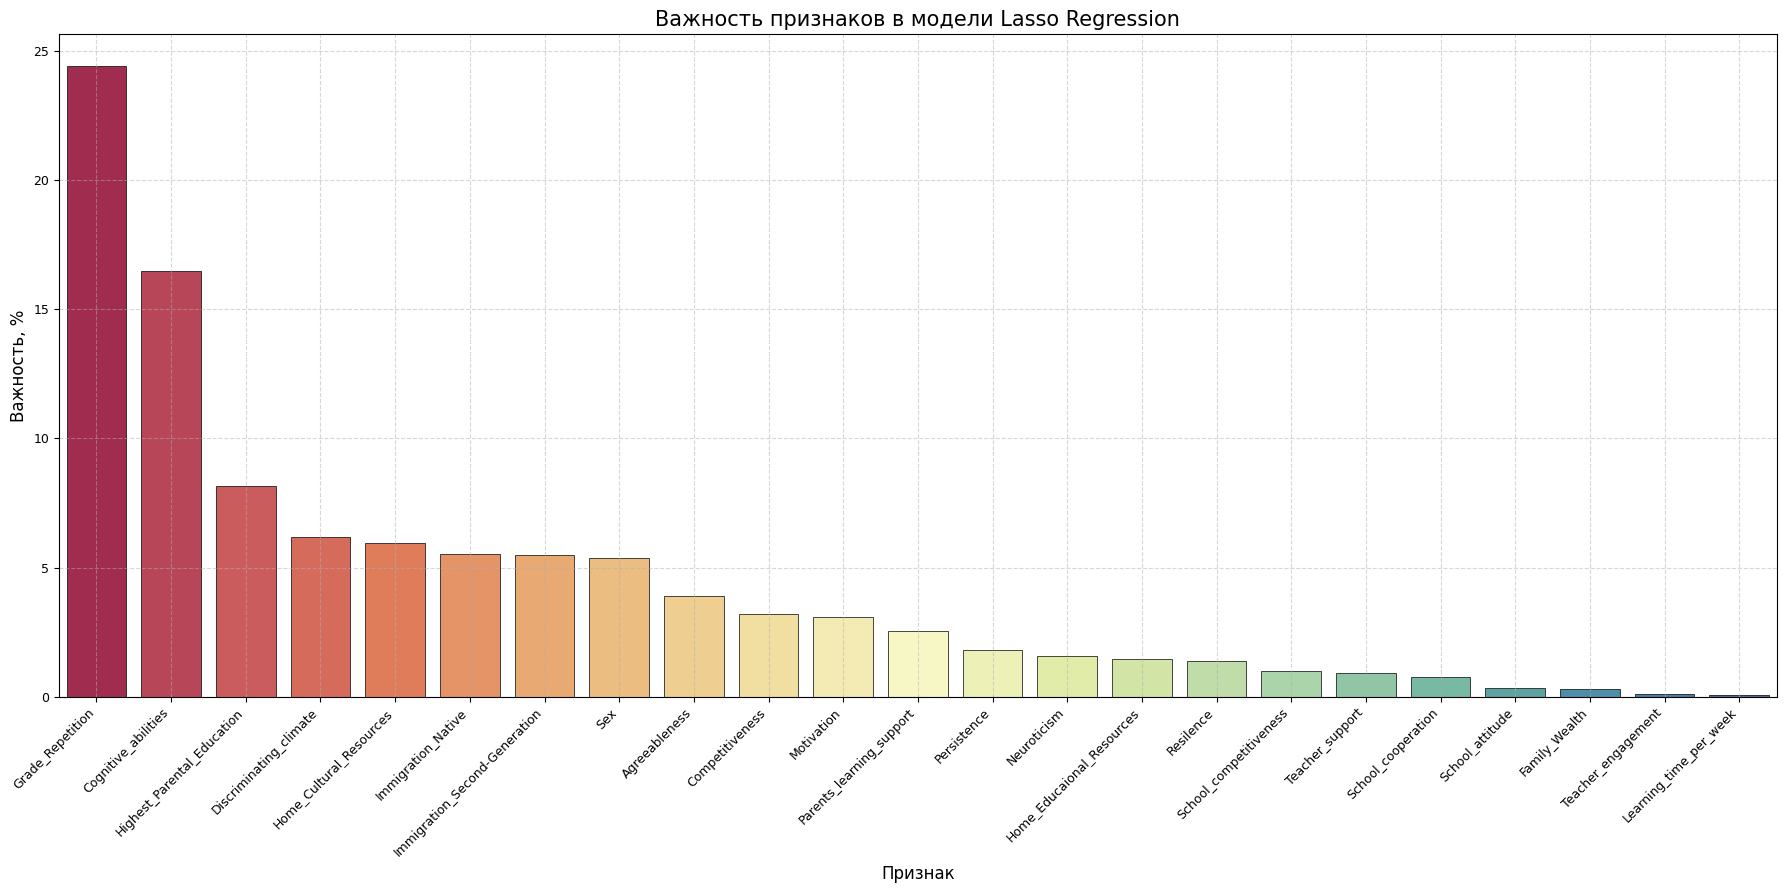

In [121]:
coef_table = pd.DataFrame({'Feature': features, 'Coefficient': l1.coef_,
                          'Absolute_value': abs(l1.coef_), 'Importance': 100 * abs(l1.coef_) / sum(abs(l1.coef_))})
coef_table = coef_table.sort_values('Importance', ascending=False)

plt.figure(figsize=(18, 9))
sns.barplot(x='Feature', y='Importance', data=coef_table, palette='Spectral', edgecolor='black', linewidth=0.5)
plt.title('Важность признаков в модели Lasso Regression', fontsize=15)
plt.xlabel('Признак', fontsize=12)
plt.ylabel('Важность, %', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [122]:
print("Важность признаков в модели:")
coef_table.reset_index(drop=True)

Важность признаков в модели:


,Feature,Coefficient,Absolute_value,Importance
0,Grade_Repetition,-452.966325,452.966325,24.425045
1,Сognitive_abilities,305.344536,305.344536,16.464919
2,Highest_Parental_Education,151.369171,151.369171,8.162194
3,Discriminating_climate,-114.733784,114.733784,6.186724
4,Home_Cultural_Resources,110.301514,110.301514,5.947726
5,Immigration_Native,102.576786,102.576786,5.531190
6,Immigration_Second-Generation,101.754489,101.754489,5.486849
7,Sex,-99.723371,99.723371,5.377326
8,Agreeableness,72.316215,72.316215,3.899466
9,Competitiveness,59.139635,59.139635,3.188953


### 2.1.4. Реализация и оценка качества модели Decision Tree

Построенные ранее линейные модели были способны улавливать исключительно линейные взаимосвязи, поэтому для учета нелинейных взаимосвязей в данных была использованная древовидная модель - Decision Tree. В отличие от линейных моделей, дерево решений не предполагает заранее заданной функциональной формы связи между признаками и таргет-переменной, что делает его подходящим инструментом для исследования сложных зависимостей. Для подбора гиперпараметров, контролирующих глубину дерева, минимальное количество образцов в листе и других параметров регуляризации, был применен метод случайного поиска, позволяющий оптимизировать скорость поиска подходящих гиперпараметров и демонстрирующих качество выбора, сопоставимое с результатом полного перебора.

In [123]:
params_dt = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_leaf': [10, 20, 50, 100, 200],
    'min_samples_split': [20, 50, 100, 200],
    'max_features': ['sqrt', 'log2', None]
}

dt = DecisionTreeRegressor(random_state=42)

dt_search = RandomizedSearchCV(dt, param_distributions=params_dt, n_iter=50, cv=5,
                               scoring='neg_mean_squared_error', random_state=42, n_jobs=-1, verbose=1)

dt_search.fit(X_train_lin, y_train_reg, sample_weight=w_train)
y_pred_train_dt = dt_search.predict(X_train_lin)
y_pred_test_dt = dt_search.predict(X_test_lin)

print(f'Взвешенный RMSE для обучающей выборки равен {weighted_rmse(y_train_reg, y_pred_train_dt, w_train)}')
print(f'Взвешенный RMSE для тестовой выборки равен {weighted_rmse(y_test_reg, y_pred_test_dt, w_test)}')
print()
print(f'Взвешеная MAE для обучающей выборки равна {weighted_mae(y_train_reg, y_pred_train_dt, w_train)}')
print(f'Взвешеная MAE для тестовой выборки равна {weighted_mae(y_test_reg, y_pred_test_dt, w_test)}')
print()
print(f'Взвешенный R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_dt, sample_weight=w_train)}')
print(f'Взвешенный R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_dt, sample_weight=w_test)}')
print()
print(f'RMSE для обучающей выборки равен {RMSE(y_train_reg, y_pred_train_dt)}')
print(f'RMSE для тестовой выборки равен {RMSE(y_test_reg, y_pred_test_dt)}')
print()
print(f'MAE для обучающей выборки равна {MAE(y_train_reg, y_pred_train_dt)}')
print(f'MAE для тестовой выборки равна {MAE(y_test_reg, y_pred_test_dt)}')
print()
print(f'R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_dt)}')
print(f'R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_dt)}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Взвешенный RMSE для обучающей выборки равен 628.0258001661887
Взвешенный RMSE для тестовой выборки равен 652.0339377258005

Взвешеная MAE для обучающей выборки равна 499.68907837143394
Взвешеная MAE для тестовой выборки равна 516.4121072523939

Взвешенный R^2 для обучающей выборки равен 0.3620416921590992
Взвешенный R^2 для тестовой выборки равен 0.3061608709128121

RMSE для обучающей выборки равен 642.6488837755466
RMSE для тестовой выборки равен 657.0275308510472

MAE для обучающей выборки равна 512.3298697165791
MAE для тестовой выборки равна 520.7123171973557

R^2 для обучающей выборки равен 0.32585024025916964
R^2 для тестовой выборки равен 0.29413939005243905


In [124]:
from sklearn.tree import DecisionTreeRegressor
params_dt = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_leaf': [10, 20, 50, 100, 200],
    'min_samples_split': [20, 50, 100, 200],
    'max_features': ['sqrt', 'log2', None]
}

dt = DecisionTreeRegressor(random_state=42)

dt_search = RandomizedSearchCV(
    dt,
    param_distributions=params_dt,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

dt_search.fit(X_train_full, y_train_reg, sample_weight=w_train)
y_pred_train_dt = dt_search.predict(X_train_full)
y_pred_test_dt = dt_search.predict(X_test_full)

print(f'Взвешенный RMSE для обучающей выборки равен {weighted_rmse(y_train_reg, y_pred_train_dt, w_train)}')
print(f'Взвешенный RMSE для тестовой выборки равен {weighted_rmse(y_test_reg, y_pred_test_dt, w_test)}')
print()
print(f'Взвешеная MAE для обучающей выборки равна {weighted_mae(y_train_reg, y_pred_train_dt, w_train)}')
print(f'Взвешеная MAE для тестовой выборки равна {weighted_mae(y_test_reg, y_pred_test_dt, w_test)}')
print()
print(f'Взвешенный R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_dt, sample_weight=w_train)}')
print(f'Взвешенный R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_dt, sample_weight=w_test)}')
print()
print(f'RMSE для обучающей выборки равен {RMSE(y_train_reg, y_pred_train_dt)}')
print(f'RMSE для тестовой выборки равен {RMSE(y_test_reg, y_pred_test_dt)}')
print()
print(f'MAE для обучающей выборки равна {MAE(y_train_reg, y_pred_train_dt)}')
print(f'MAE для тестовой выборки равна {MAE(y_test_reg, y_pred_test_dt)}')
print()
print(f'R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_dt)}')
print(f'R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_dt)}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Взвешенный RMSE для обучающей выборки равен 613.964358237117
Взвешенный RMSE для тестовой выборки равен 648.0713926854319

Взвешеная MAE для обучающей выборки равна 488.9034389813619
Взвешеная MAE для тестовой выборки равна 510.71840390676044

Взвешенный R^2 для обучающей выборки равен 0.3902895382642557
Взвешенный R^2 для тестовой выборки равен 0.3145684534016605

RMSE для обучающей выборки равен 638.0270508244017
RMSE для тестовой выборки равен 654.9241396042793

MAE для обучающей выборки равна 508.21781423119904
MAE для тестовой выборки равна 517.6607237872594

R^2 для обучающей выборки равен 0.3355121363428887
R^2 для тестовой выборки равен 0.2986516042800643


In [125]:
from sklearn.tree import DecisionTreeRegressor
params_dt = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_leaf': [10, 20, 50, 100, 200],
    'min_samples_split': [20, 50, 100, 200],
    'max_features': ['sqrt', 'log2', None]
}

dt = DecisionTreeRegressor(random_state=42)

dt_search = RandomizedSearchCV(
    dt,
    param_distributions=params_dt,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

dt_search.fit(X_train_full, y_train_reg, sample_weight=w_train)
y_pred_train_dt = dt_search.predict(X_train_full)
y_pred_test_dt = dt_search.predict(X_test_full)

print(f'Взвешенный RMSE для обучающей выборки равен {weighted_rmse(y_train_reg, y_pred_train_dt, w_train)}')
print(f'Взвешенный RMSE для тестовой выборки равен {weighted_rmse(y_test_reg, y_pred_test_dt, w_test)}')
print()
print(f'Взвешеная MAE для обучающей выборки равна {weighted_mae(y_train_reg, y_pred_train_dt, w_train)}')
print(f'Взвешеная MAE для тестовой выборки равна {weighted_mae(y_test_reg, y_pred_test_dt, w_test)}')
print()
print(f'Взвешенный R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_dt, sample_weight=w_train)}')
print(f'Взвешенный R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_dt, sample_weight=w_test)}')
print()
print(f'RMSE для обучающей выборки равен {RMSE(y_train_reg, y_pred_train_dt)}')
print(f'RMSE для тестовой выборки равен {RMSE(y_test_reg, y_pred_test_dt)}')
print()
print(f'MAE для обучающей выборки равна {MAE(y_train_reg, y_pred_train_dt)}')
print(f'MAE для тестовой выборки равна {MAE(y_test_reg, y_pred_test_dt)}')
print()
print(f'R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_dt)}')
print(f'R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_dt)}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Взвешенный RMSE для обучающей выборки равен 613.964358237117
Взвешенный RMSE для тестовой выборки равен 648.0713926854319

Взвешеная MAE для обучающей выборки равна 488.9034389813619
Взвешеная MAE для тестовой выборки равна 510.71840390676044

Взвешенный R^2 для обучающей выборки равен 0.3902895382642557
Взвешенный R^2 для тестовой выборки равен 0.3145684534016605

RMSE для обучающей выборки равен 638.0270508244017
RMSE для тестовой выборки равен 654.9241396042793

MAE для обучающей выборки равна 508.21781423119904
MAE для тестовой выборки равна 517.6607237872594

R^2 для обучающей выборки равен 0.3355121363428887
R^2 для тестовой выборки равен 0.2986516042800643


In [127]:
params_dt_random_v3 = {
    'max_depth': randint(4, 12),
    'min_samples_leaf': randint(20, 150),
    'min_samples_split': randint(40, 250),
    'max_features': ['sqrt', 'log2', None],
    'min_impurity_decrease': uniform(0, 0.01),
    'ccp_alpha': uniform(0, 0.05)
}

dt_v3 = DecisionTreeRegressor(random_state=42)

dt_search_v3 = RandomizedSearchCV(
    dt_v3,
    param_distributions=params_dt_random_v3,
    n_iter=100,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

dt_search_v3.fit(X_train_full, y_train_reg, sample_weight=w_train)

print(f"Best parameters: {dt_search_v3.best_params_}")

dt_best = dt_search_v3.best_estimator_

y_pred_train_dt3 = dt_best.predict(X_train_full)
y_pred_test_dt3 = dt_best.predict(X_test_full)

print(f'Взвешенный RMSE для обучающей выборки равен {weighted_rmse(y_train_reg, y_pred_train_dt3, w_train)}')
print(f'Взвешенный RMSE для тестовой выборки равен {weighted_rmse(y_test_reg, y_pred_test_dt3, w_test)}')
print()
print(f'Взвешеная MAE для обучающей выборки равна {weighted_mae(y_train_reg, y_pred_train_dt3, w_train)}')
print(f'Взвешеная MAE для тестовой выборки равна {weighted_mae(y_test_reg, y_pred_test_dt3, w_test)}')
print()
print(f'Взвешенный R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_dt3, sample_weight=w_train)}')
print(f'Взвешенный R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_dt3, sample_weight=w_test)}')
print()
print(f'RMSE для обучающей выборки равен {RMSE(y_train_reg, y_pred_train_dt3)}')
print(f'RMSE для тестовой выборки равен {RMSE(y_test_reg, y_pred_test_dt3)}')
print()
print(f'MAE для обучающей выборки равна {MAE(y_train_reg, y_pred_train_dt3)}')
print(f'MAE для тестовой выборки равна {MAE(y_test_reg, y_pred_test_dt3)}')
print()
print(f'R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_dt3)}')
print(f'R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_dt3)}')


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters: {'ccp_alpha': np.float64(0.04433401936490238), 'max_depth': 7, 'max_features': None, 'min_impurity_decrease': np.float64(0.0001530454029038475), 'min_samples_leaf': 115, 'min_samples_split': 40}
Взвешенный RMSE для обучающей выборки равен 617.0727451566473
Взвешенный RMSE для тестовой выборки равен 644.1913474775364

Взвешеная MAE для обучающей выборки равна 491.6673174901063
Взвешеная MAE для тестовой выборки равна 506.5360683458168

Взвешенный R^2 для обучающей выборки равен 0.3841002096463427
Взвешенный R^2 для тестовой выборки равен 0.32275132986416655

RMSE для обучающей выборки равен 639.7050593246971
RMSE для тестовой выборки равен 654.554008327727

MAE для обучающей выборки равна 509.9027213917294
MAE для тестовой выборки равна 516.7121789761778

R^2 для обучающей выборки равен 0.332012339504431
R^2 для тестовой выборки равен 0.29944411628939094


В рамках построения модели типа Decision Tree было создано четыре различные версии. Лучшая версия модели указанного типа после настройки гиперпараметров продемонстрировала на тестовой выборке среднеквадратическую ошибку ($RMSE$)  равную 654.55 баллам, среднюю абсолютную ошибку ($MAE$) равную 516.71 баллу и коэффициент детерминации ($R^2$) равный 0.299. При этом оптимальная конфигурация гиперпараметров была следующей: max_depth = 7; min_samples_leaf = 115; min_samples_split = 40; max_features = None; ccp_alpha ~ 0.0443; min_impurity_decrease ~ 0.000153. Тем не менее, метрики качества модели не показали значимого превосходства над метриками, рассчитанными для линейных моделей.


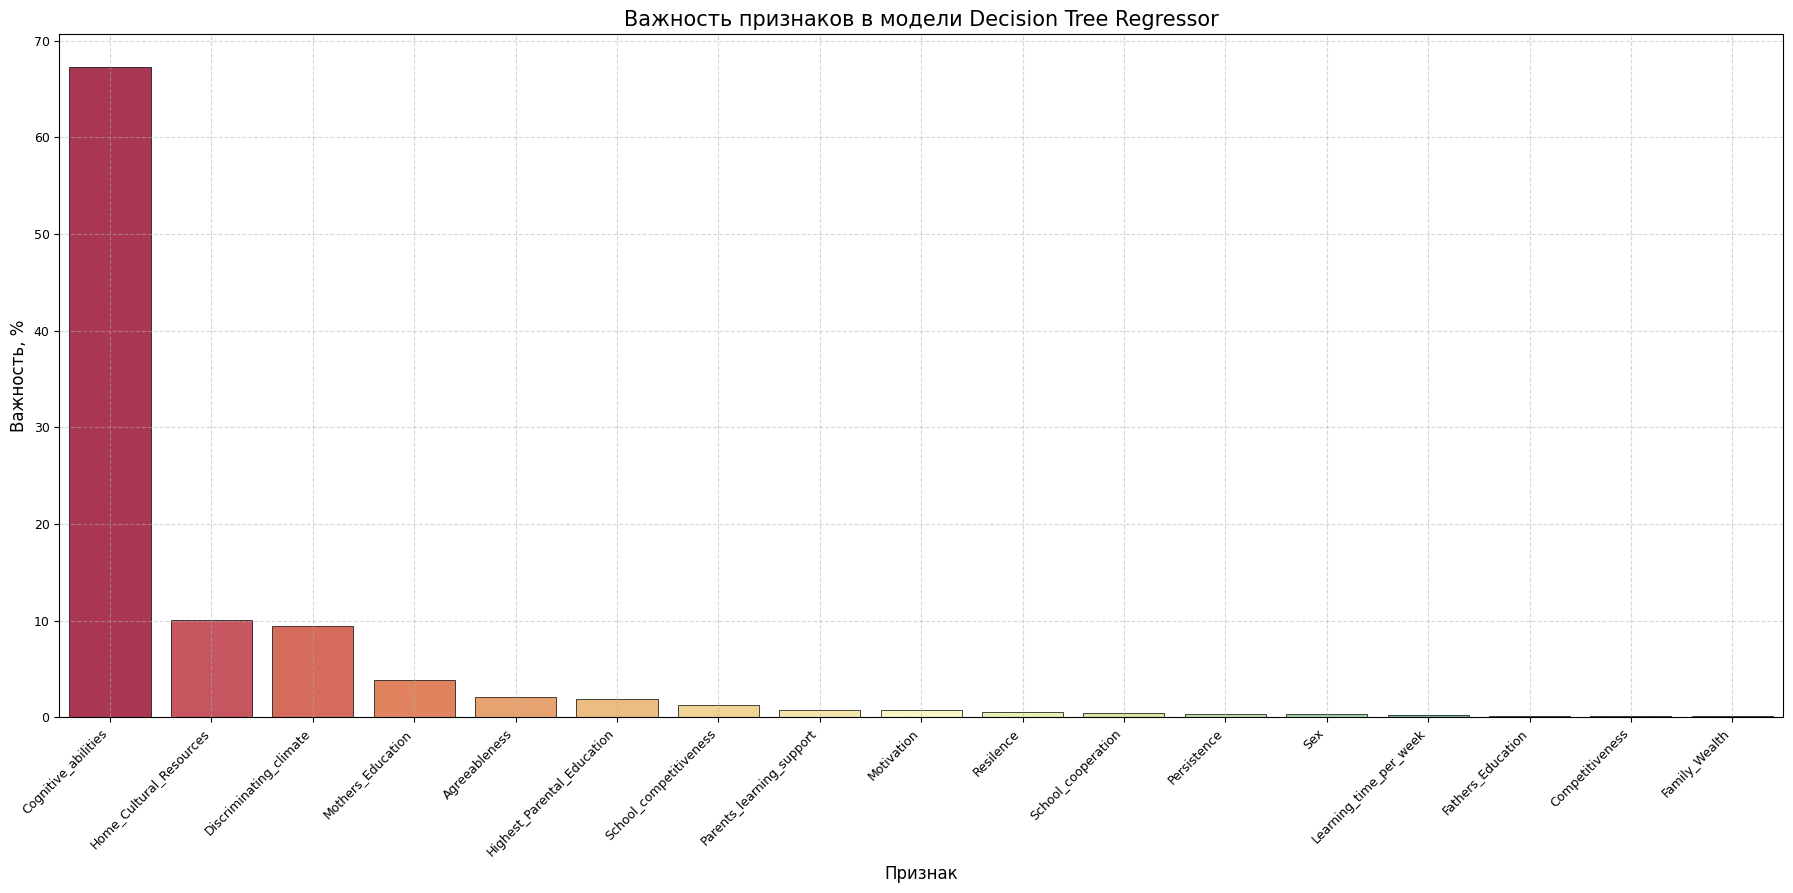

In [128]:
feature_importance = dt_best.feature_importances_
features = X_train_full.columns

importance_table = pd.DataFrame({'Feature': features, 'Importance': feature_importance,
                                 'Importance_percent': 100 * abs(feature_importance) / np.sum(abs(feature_importance))})

importance_table = importance_table.sort_values('Importance_percent', ascending=False)

plt.figure(figsize=(18, 9))
sns.barplot(x='Feature', y='Importance_percent', data=importance_table.iloc[0:17], palette='Spectral', edgecolor='black', linewidth=0.5)

plt.title('Важность признаков в модели Decision Tree Regressor', fontsize=15)
plt.xlabel('Признак', fontsize=12)
plt.ylabel('Важность, %', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [129]:
print("Топ наиболее важных признаков:")
importance_table.head(17).reset_index(drop=True)

Топ наиболее важных признаков:


,Feature,Importance,Importance_percent
0,Сognitive_abilities,0.672839,67.283949
1,Home_Cultural_Resources,0.100904,10.090431
2,Discriminating_climate,0.094676,9.467638
3,Mothers_Education,0.038447,3.844721
4,Agreeableness,0.020873,2.087346
5,Highest_Parental_Education,0.019364,1.936428
6,School_competitiveness,0.012912,1.291182
7,Parents_learning_support,0.007755,0.775511
8,Motivation,0.007666,0.766557
9,Resilence,0.005585,0.558484


### 2.1.5. Реализация и оценка качества модели Random Forest

В качестве одного из направлений улучшений для уже построенных прогностических моделей был использован ансамблевый алгоритм, основанный на построении множества деревьев решений - Random Forest. Данный метод, снижающий дисперсию предсказаний за счет бэггинга, был выбран в том числе из-за его устойчивости к выбросам, высокой эффективности в многомерном пространстве и отсутствии требований к предварительной стандартизации данных. Для достижения максимальной производительности в рамках реализации алгоритма был проведен многоступенчатый подбор гиперпараметров с использованием RandomizedSearchCV, включая оптимизацию количества деревьев, максимальной глубины, минимального числа образцов в листе и доли выборки для обучения каждого дерева. Также в качестве гиперпараметра использовался аргумент, определяющий субвыборку и таким образом снижающий корреляцию между деревьями в ансамбле.

In [130]:
param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_leaf': [5, 10, 20, 50],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_distributions,
    n_iter=30,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_full, y_train_reg, sample_weight=w_train)

y_pred_train_rf = rf_search.predict(X_train_full)
y_pred_test_rf = rf_search.predict(X_test_full)

print(f'Взвешенный RMSE для обучающей выборки равен {weighted_rmse(y_train_reg, y_pred_train_rf, w_train)}')
print(f'Взвешенный RMSE для тестовой выборки равен {weighted_rmse(y_test_reg, y_pred_test_rf, w_test)}')
print()
print(f'Взвешеная MAE для обучающей выборки равна {weighted_mae(y_train_reg, y_pred_train_rf, w_train)}')
print(f'Взвешеная MAE для тестовой выборки равна {weighted_mae(y_test_reg, y_pred_test_rf, w_test)}')
print()
print(f'Взвешенный R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_rf, sample_weight=w_train)}')
print(f'Взвешенный R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_rf, sample_weight=w_test)}')
print()
print(f'RMSE для обучающей выборки равен {RMSE(y_train_reg, y_pred_train_rf)}')
print(f'RMSE для тестовой выборки равен {RMSE(y_test_reg, y_pred_test_rf)}')
print()
print(f'MAE для обучающей выборки равна {MAE(y_train_reg, y_pred_train_rf)}')
print(f'MAE для тестовой выборки равна {MAE(y_test_reg, y_pred_test_rf)}')
print()
print(f'R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_rf)}')
print(f'R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_rf)}')

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Взвешенный RMSE для обучающей выборки равен 410.06098239408294
Взвешенный RMSE для тестовой выборки равен 606.7911075838233

Взвешеная MAE для обучающей выборки равна 319.57732248508324
Взвешеная MAE для тестовой выборки равна 484.50872530341786

Взвешенный R^2 для обучающей выборки равен 0.7280217205935954
Взвешенный R^2 для тестовой выборки равен 0.39910747469942953

RMSE для обучающей выборки равен 501.8370370749648
RMSE для тестовой выборки равен 617.0992033704584

MAE для обучающей выборки равна 392.01958492678017
MAE для тестовой выборки равна 490.99094911100445

R^2 для обучающей выборки равен 0.5889124825361549
R^2 для тестовой выборки равен 0.37732449304231286


In [131]:
param_distributions_v2 = {
    'n_estimators': [300, 500, 700],
    'max_depth': [5, 7, 10, 12],
    'min_samples_leaf': [20, 30, 50, 100],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [10, 20, 30],
    'max_samples': [0.6, 0.7, 0.8]
}

rf_v2 = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_search_v2 = RandomizedSearchCV(
    rf_v2,
    param_distributions=param_distributions_v2,
    n_iter=40,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search_v2.fit(X_train_full, y_train_reg, sample_weight=w_train)
rf_best_v2 = rf_search_v2.best_estimator_
y_pred_train_rf2 = rf_search_v2.predict(X_train_full)
y_pred_test_rf2 = rf_search_v2.predict(X_test_full)

print(f'Взвешенный RMSE для обучающей выборки равен {weighted_rmse(y_train_reg, y_pred_train_rf2, w_train)}')
print(f'Взвешенный RMSE для тестовой выборки равен {weighted_rmse(y_test_reg, y_pred_test_rf2, w_test)}')
print()
print(f'Взвешеная MAE для обучающей выборки равна {weighted_mae(y_train_reg, y_pred_train_rf2, w_train)}')
print(f'Взвешеная MAE для тестовой выборки равна {weighted_mae(y_test_reg, y_pred_test_rf2, w_test)}')
print()
print(f'Взвешенный R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_rf2, sample_weight=w_train)}')
print(f'Взвешенный R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_rf2, sample_weight=w_test)}')
print()
print(f'RMSE для обучающей выборки равен {RMSE(y_train_reg, y_pred_train_rf2)}')
print(f'RMSE для тестовой выборки равен {RMSE(y_test_reg, y_pred_test_rf2)}')
print()
print(f'MAE для обучающей выборки равна {MAE(y_train_reg, y_pred_train_rf2)}')
print(f'MAE для тестовой выборки равна {MAE(y_test_reg, y_pred_test_rf2)}')
print()
print(f'R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_rf2)}')
print(f'R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_rf2)}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Взвешенный RMSE для обучающей выборки равен 548.2189376510805
Взвешенный RMSE для тестовой выборки равен 615.1563698324304

Взвешеная MAE для обучающей выборки равна 435.2507432885917
Взвешеная MAE для тестовой выборки равна 492.07028996273596

Взвешенный R^2 для обучающей выборки равен 0.5138778681376246
Взвешенный R^2 для тестовой выборки равен 0.3824253836927114

RMSE для обучающей выборки равен 585.2852674955357
RMSE для тестовой выборки равен 623.9696612678641

MAE для обучающей выборки равна 466.64037620589585
MAE для тестовой выборки равна 497.1796496067694

R^2 для обучающей выборки равен 0.44082975439644356
R^2 для тестовой выборки равен 0.36338222671577114


In [132]:
param_distributions_v3 = {
    'n_estimators': [500, 700, 1000],
    'max_depth': [4, 5, 6, 7],
    'min_samples_leaf': [50, 75, 100, 150],
    'max_features': ['sqrt'],
    'min_samples_split': [20, 30, 50],
    'max_samples': [0.5, 0.6, 0.7]
}

rf_v3 = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_search_v3 = RandomizedSearchCV(
    rf_v3,
    param_distributions=param_distributions_v3,
    n_iter=40,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search_v3.fit(X_train_full, y_train_reg, sample_weight=w_train)

rf_best_v3 = rf_search_v3.best_estimator_
y_pred_train_rf3 = rf_best_v3.predict(X_train_full)
y_pred_test_rf3 = rf_best_v3.predict(X_test_full)

print(f'Взвешенный RMSE для обучающей выборки равен {weighted_rmse(y_train_reg, y_pred_train_rf3, w_train)}')
print(f'Взвешенный RMSE для тестовой выборки равен {weighted_rmse(y_test_reg, y_pred_test_rf3, w_test)}')
print()
print(f'Взвешеная MAE для обучающей выборки равна {weighted_mae(y_train_reg, y_pred_train_rf3, w_train)}')
print(f'Взвешеная MAE для тестовой выборки равна {weighted_mae(y_test_reg, y_pred_test_rf3, w_test)}')
print()
print(f'Взвешенный R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_rf3, sample_weight=w_train)}')
print(f'Взвешенный R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_rf3, sample_weight=w_test)}')
print()
print(f'RMSE для обучающей выборки равен {RMSE(y_train_reg, y_pred_train_rf3)}')
print(f'RMSE для тестовой выборки равен {RMSE(y_test_reg, y_pred_test_rf3)}')
print()
print(f'MAE для обучающей выборки равна {MAE(y_train_reg, y_pred_train_rf3)}')
print(f'MAE для тестовой выборки равна {MAE(y_test_reg, y_pred_test_rf3)}')
print()
print(f'R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_rf3)}')
print(f'R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_rf3)}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Взвешенный RMSE для обучающей выборки равен 609.7226826227163
Взвешенный RMSE для тестовой выборки равен 631.9965737172637

Взвешеная MAE для обучающей выборки равна 485.68686222188785
Взвешеная MAE для тестовой выборки равна 506.28569381437

Взвешенный R^2 для обучающей выборки равен 0.3986850106905925
Взвешенный R^2 для тестовой выборки равен 0.3481497535617467

RMSE для обучающей выборки равен 624.0771411651631
RMSE для тестовой выборки равен 639.0345958042344

MAE для обучающей выборки равна 499.4110126246949
MAE для тестовой выборки равна 509.67154148063906

R^2 для обучающей выборки равен 0.3642513891888931
R^2 для тестовой выборки равен 0.33227051724007917


In [134]:
print(f"Best parameters: {rf_search_v3.best_params_}")

Best parameters: {'n_estimators': 500, 'min_samples_split': 30, 'min_samples_leaf': 50, 'max_samples': 0.7, 'max_features': 'sqrt', 'max_depth': 7}


Random Forest Regressor стал первой моделью, которая продемонстрировала качественный скачок в точности предсказаний: после настройки гиперпараметров на тестовой выборке среднеквадратическая ошибка ($RMSE$) для лучшей из трех версий модели составила 630.03 баллов, средняя абсолютная ошибка ($MAE$) – 509.67 баллов, а коэффициент детерминации ($R^2$) – 0.364. Лучшей комбинацией гиперпараметров при этом стала комбинация, где n_estimators = 500; max_depth = 7; min_samples_split = 30; min_samples_leaf = 50; max_samples = 0.7; max_features: 'sqrt'. Благодаря ансамблированию и усреднению, модель оказалась значительно устойчивее к переобучению, чем одиночное дерево.

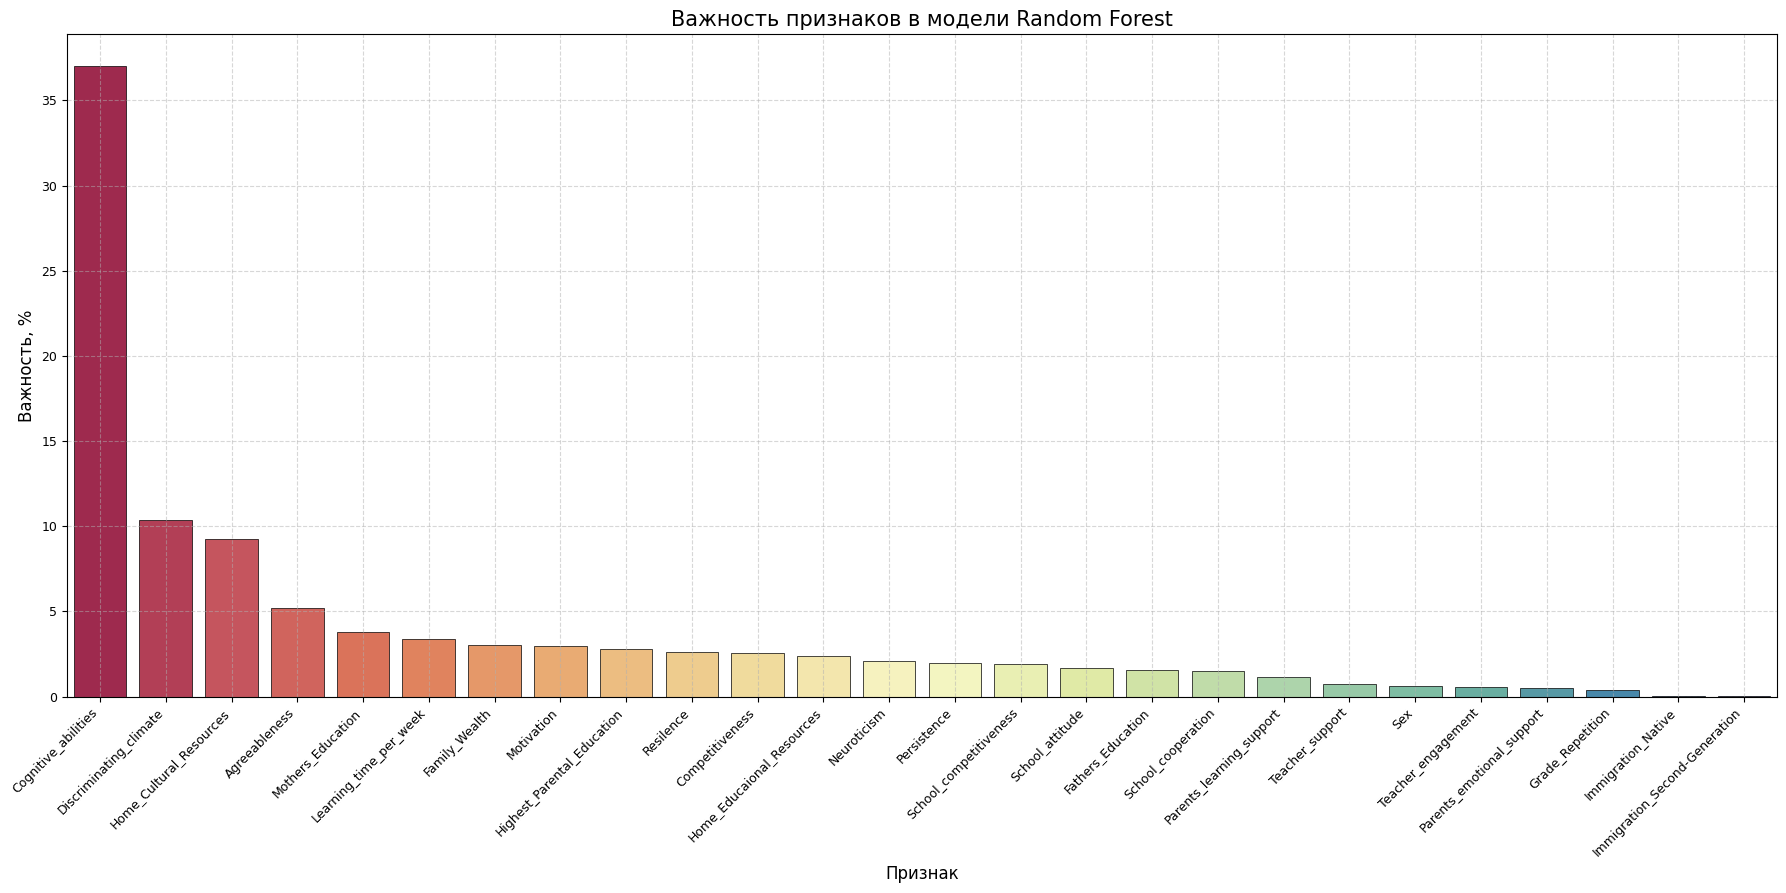

In [86]:
feature_importance = rf_best_v2.feature_importances_
features = X_train_full.columns

importance_table = pd.DataFrame({'Feature': features, 'Importance': feature_importance,
                                 'Importance_percent': 100 * abs(feature_importance) / np.sum(abs(feature_importance))})

importance_table = importance_table.sort_values('Importance_percent', ascending=False)

plt.figure(figsize=(18, 9))
sns.barplot(x='Feature', y='Importance_percent', data=importance_table, palette='Spectral', edgecolor='black', linewidth=0.5)

plt.title('Важность признаков в модели Random Forest', fontsize=15)
plt.xlabel('Признак', fontsize=12)
plt.ylabel('Важность, %', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [87]:
print("Важность признаков в модели:")
importance_table.reset_index(drop=True)

Важность признаков в модели:


,Feature,Importance,Importance_percent
0,Сognitive_abilities,0.370274,37.027438
1,Discriminating_climate,0.103489,10.348909
2,Home_Cultural_Resources,0.092321,9.232079
3,Agreeableness,0.052004,5.200380
4,Mothers_Education,0.037714,3.771399
5,Learning_time_per_week,0.033743,3.374295
6,Family_Wealth,0.030034,3.003379
7,Motivation,0.029632,2.963237
8,Highest_Parental_Education,0.027791,2.779101
9,Resilence,0.026168,2.616794


### 2.1.6. Реализация и оценка качества модели HistGradientBoosting

Выбор HistGradientBoosting — одного из видов градиентного бустинга — для построения прогнозов был обусловлен его высокой доказанной эффективностью на табличных данных со смешанными типами признаков, к которым относятся и данные, используемые в рамках текущей работы. Также причиной выбора метода стала высокая вычислительная скорость. Для настройки гиперпараметров HistGradientBoostingRegressor был применен ручной подбор вместо автоматизированных методов поиска, что было обусловлено наличием встроенного механизма ранней остановки. Поскольку данный инструмент позволяет оценивать качество на валидационной выборке в процессе обучения и автоматически прекращать добавление деревьев при отсутствии улучшений, полный перебор гиперпараметров становится избыточным.

In [88]:
gb = HistGradientBoostingRegressor(
    max_depth=8,
    learning_rate=0.08,
    max_iter=300,
    min_samples_leaf=30,
    random_state=42,
    early_stopping=True
)

gb.fit(X_train_full, y_train_reg, sample_weight=w_train)
y_pred_train_gb = gb.predict(X_train_full)
y_pred_test_gb = gb.predict(X_test_full)

print(f'Взвешенный RMSE для обучающей выборки равен {weighted_rmse(y_train_reg, y_pred_train_gb, w_train)}')
print(f'Взвешенный RMSE для тестовой выборки равен {weighted_rmse(y_test_reg, y_pred_test_gb, w_test)}')
print()
print(f'Взвешеная MAE для обучающей выборки равна {weighted_mae(y_train_reg, y_pred_train_gb, w_train)}')
print(f'Взвешеная MAE для тестовой выборки равна {weighted_mae(y_test_reg, y_pred_test_gb, w_test)}')
print()
print(f'Взвешенный R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_gb, sample_weight=w_train)}')
print(f'Взвешенный R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_gb, sample_weight=w_test)}')
print()
print(f'RMSE для обучающей выборки равен {RMSE(y_train_reg, y_pred_train_gb)}')
print(f'RMSE для тестовой выборки равен {RMSE(y_test_reg, y_pred_test_gb)}')
print()
print(f'MAE для обучающей выборки равна {MAE(y_train_reg, y_pred_train_gb)}')
print(f'MAE для тестовой выборки равна {MAE(y_test_reg, y_pred_test_gb)}')
print()
print(f'R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_gb)}')
print(f'R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_gb)}')

Взвешенный RMSE для обучающей выборки равен 461.4252137787504
Взвешенный RMSE для тестовой выборки равен 593.1584690603232

Взвешеная MAE для обучающей выборки равна 360.73976659033434
Взвешеная MAE для тестовой выборки равна 467.9530446537925

Взвешенный R^2 для обучающей выборки равен 0.6556183752989397
Взвешенный R^2 для тестовой выборки равен 0.42580440345841264

RMSE для обучающей выборки равен 536.9789515021255
RMSE для тестовой выборки равен 606.9550159316981

MAE для обучающей выборки равна 422.4742167311991
MAE для тестовой выборки равна 480.6374259840479

R^2 для обучающей выборки равен 0.5293225476098102
R^2 для тестовой выборки равен 0.3976279379779446


In [89]:
gb = HistGradientBoostingRegressor(
    max_depth=5,
    max_iter=150,
    min_samples_leaf=60,
    learning_rate=0.04,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.15,
    tol=1e-4,
    n_iter_no_change=15,
    random_state=42,
    verbose=1
)

gb.fit(X_train_full, y_train_reg, sample_weight=w_train)

y_pred_train_gb = gb.predict(X_train_full)
y_pred_test_gb = gb.predict(X_test_full)

print(f'Взвешенный RMSE для обучающей выборки равен {weighted_rmse(y_train_reg, y_pred_train_gb, w_train)}')
print(f'Взвешенный RMSE для тестовой выборки равен {weighted_rmse(y_test_reg, y_pred_test_gb, w_test)}')
print()
print(f'Взвешеная MAE для обучающей выборки равна {weighted_mae(y_train_reg, y_pred_train_gb, w_train)}')
print(f'Взвешеная MAE для тестовой выборки равна {weighted_mae(y_test_reg, y_pred_test_gb, w_test)}')
print()
print(f'Взвешенный R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_gb, sample_weight=w_train)}')
print(f'Взвешенный R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_gb, sample_weight=w_test)}')
print()
print(f'RMSE для обучающей выборки равен {RMSE(y_train_reg, y_pred_train_gb)}')
print(f'RMSE для тестовой выборки равен {RMSE(y_test_reg, y_pred_test_gb)}')
print()
print(f'MAE для обучающей выборки равна {MAE(y_train_reg, y_pred_train_gb)}')
print(f'MAE для тестовой выборки равна {MAE(y_test_reg, y_pred_test_gb)}')
print()
print(f'R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_gb)}')
print(f'R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_gb)}')

Binning 0.002 GB of training data: 0.027 s
Binning 0.000 GB of validation data: 0.003 s
Fitting gradient boosted rounds:
Fit 150 trees in 0.664 s, (3324 total leaves)
Time spent computing histograms: 0.281s
Time spent finding best splits:  0.071s
Time spent applying splits:      0.096s
Time spent predicting:           0.009s
Взвешенный RMSE для обучающей выборки равен 536.7877680799241
Взвешенный RMSE для тестовой выборки равен 597.8163694240565

Взвешеная MAE для обучающей выборки равна 426.0395047399184
Взвешеная MAE для тестовой выборки равна 472.9608385463372

Взвешенный R^2 для обучающей выборки равен 0.5339392301914885
Взвешенный R^2 для тестовой выборки равен 0.41675101475306553

RMSE для обучающей выборки равен 575.2636285746281
RMSE для тестовой выборки равен 607.1719369941974

MAE для обучающей выборки равна 457.94673078165664
MAE для тестовой выборки равна 480.61126235834615

R^2 для обучающей выборки равен 0.4598147745662906
R^2 для тестовой выборки равен 0.3971972947374802

In [90]:
gb_less_overfit = HistGradientBoostingRegressor(
    max_depth=4,
    max_iter=175,
    min_samples_leaf=100,
    learning_rate=0.04,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42,
    verbose=1
)

gb_less_overfit.fit(X_train_full, y_train_reg, sample_weight=w_train)

y_pred_train_gb_lo = gb_less_overfit.predict(X_train_full)
y_pred_test_gb_lo = gb_less_overfit.predict(X_test_full)

print(f'Взвешенный RMSE для обучающей выборки равен {weighted_rmse(y_train_reg, y_pred_train_gb_lo, w_train)}')
print(f'Взвешенный RMSE для тестовой выборки равен {weighted_rmse(y_test_reg, y_pred_test_gb_lo, w_test)}')
print()
print(f'Взвешеная MAE для обучающей выборки равна {weighted_mae(y_train_reg, y_pred_train_gb_lo, w_train)}')
print(f'Взвешеная MAE для тестовой выборки равна {weighted_mae(y_test_reg, y_pred_test_gb_lo, w_test)}')
print()
print(f'Взвешенный R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_gb_lo, sample_weight=w_train)}')
print(f'Взвешенный R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_gb_lo, sample_weight=w_test)}')
print()
print(f'RMSE для обучающей выборки равен {RMSE(y_train_reg, y_pred_train_gb_lo)}')
print(f'RMSE для тестовой выборки равен {RMSE(y_test_reg, y_pred_test_gb_lo)}')
print()
print(f'MAE для обучающей выборки равна {MAE(y_train_reg, y_pred_train_gb_lo)}')
print(f'MAE для тестовой выборки равна {MAE(y_test_reg, y_pred_test_gb_lo)}')
print()
print(f'R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_gb_lo)}')
print(f'R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_gb_lo)}')

Binning 0.002 GB of training data: 0.024 s
Binning 0.000 GB of validation data: 0.003 s
Fitting gradient boosted rounds:
Fit 175 trees in 0.577 s, (2225 total leaves)
Time spent computing histograms: 0.259s
Time spent finding best splits:  0.049s
Time spent applying splits:      0.074s
Time spent predicting:           0.008s
Взвешенный RMSE для обучающей выборки равен 557.8095517300917
Взвешенный RMSE для тестовой выборки равен 597.160790800183

Взвешеная MAE для обучающей выборки равна 444.6780281679314
Взвешеная MAE для тестовой выборки равна 472.09558709135894

Взвешенный R^2 для обучающей выборки равен 0.496720524259714
Взвешенный R^2 для тестовой выборки равен 0.41802952076731936

RMSE для обучающей выборки равен 584.8613614850466
RMSE для тестовой выборки равен 606.2495385772211

MAE для обучающей выборки равна 466.9535192850394
MAE для тестовой выборки равна 479.8667824062851

R^2 для обучающей выборки равен 0.4416394443099494
R^2 для тестовой выборки равен 0.39902742514724776


HistGradientBoostingRegressor продемонстрировал значительное преимущество над Random Forest. Коэффициент детерминации для лучшей модели ($R^2$) при этом был равен 0.399, средняя абсолютная ошибка ($MAE$) – 479.87 баллам, а среднеквадратическая ошибка ($RMSE$) – 606.25 баллам. Значения использованных гиперпараметров при этом равнялись следующим величинам: max_depth = 4; max_iter = 175; min_samples_leaf = 100; learning_rate = 0.04; l2_regularization = 1.0; early_stopping = True; validation_fraction = 0.15;  n_iter_no_change = 15. Таким образом, рассчитанные для данного типа моделей метрики качества подтвердили высокую эффективность последовательных ансамблевых методов для решения задачи предсказания образовательных результатов школьников.

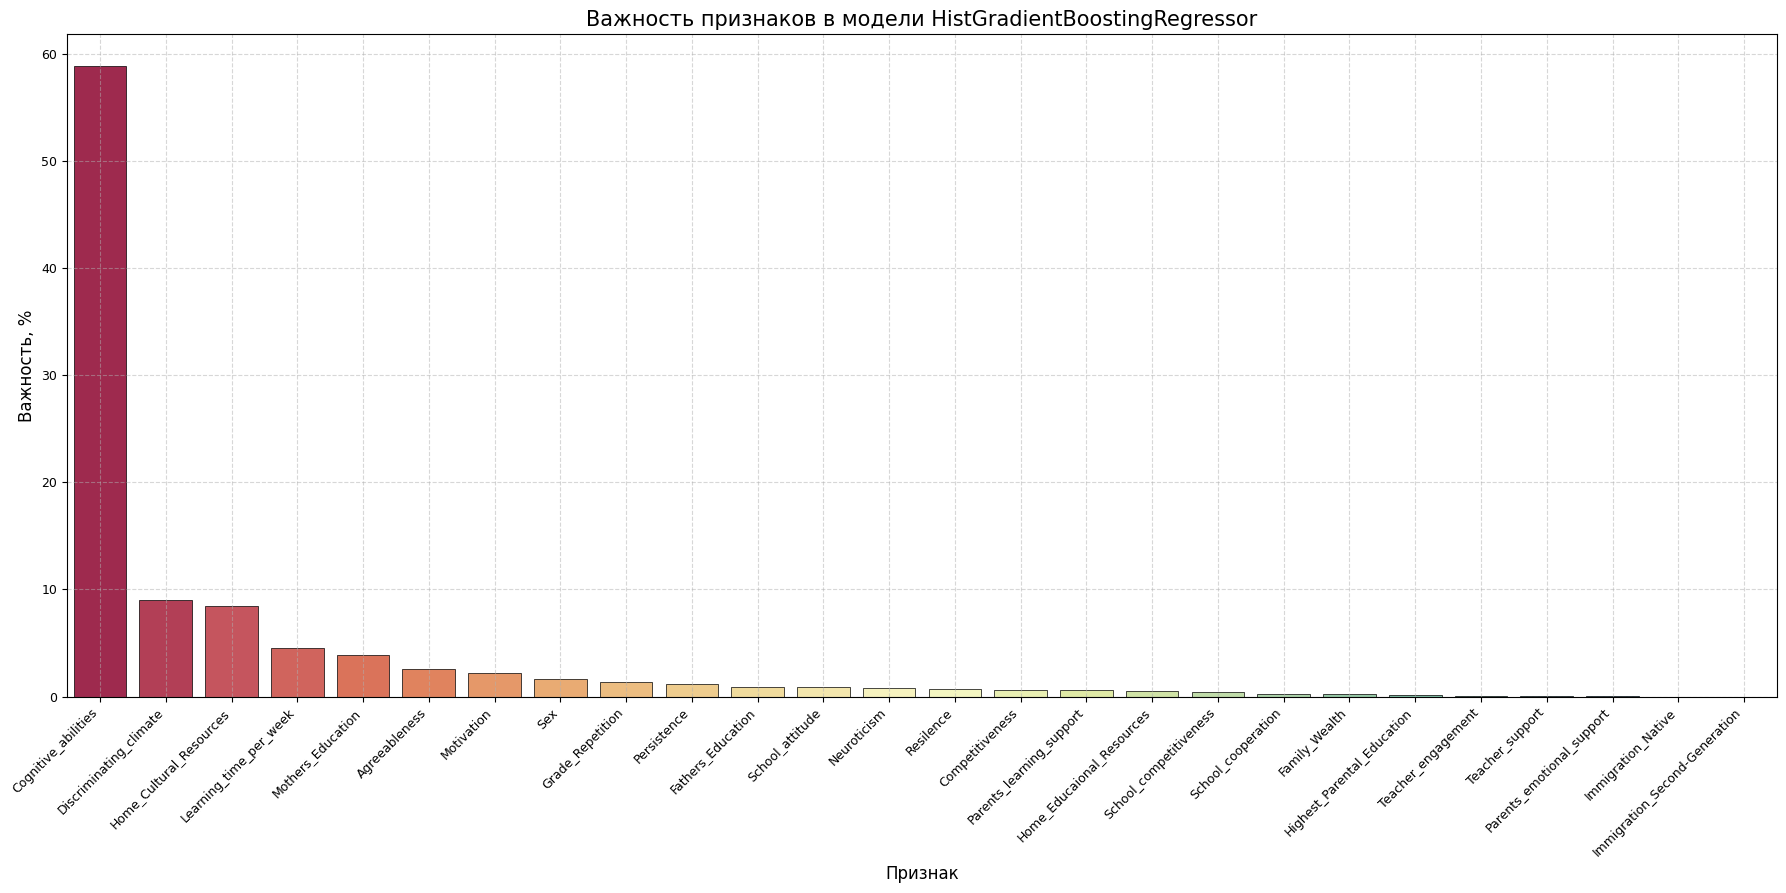

In [91]:
perm_importance = permutation_importance(
    gb_less_overfit,
    X_test_full,
    y_test_reg,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance = perm_importance.importances_mean
features = X_train_full.columns

importance_percent = 100 * abs(feature_importance) / np.sum(abs(feature_importance))

importance_table = pd.DataFrame({'Feature': features, 'Importance': feature_importance,
                                 'Importance_percent': 100 * abs(feature_importance) / np.sum(abs(feature_importance))})
importance_table = importance_table.sort_values('Importance_percent', ascending=False)

plt.figure(figsize=(18, 9))
sns.barplot(x='Feature', y='Importance_percent', data=importance_table, palette='Spectral', edgecolor='black', linewidth=0.5)

plt.title('Важность признаков в модели HistGradientBoostingRegressor', fontsize=15)
plt.xlabel('Признак', fontsize=12)
plt.ylabel('Важность, %', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [92]:
print("Важность признаков в модели:")
importance_table.reset_index(drop=True)

Важность признаков в модели:


,Feature,Importance,Importance_percent
0,Сognitive_abilities,0.313703,58.861860
1,Discriminating_climate,0.048145,9.033773
2,Home_Cultural_Resources,0.044882,8.421411
3,Learning_time_per_week,0.024067,4.515789
4,Mothers_Education,0.020942,3.929434
5,Agreeableness,0.013826,2.594164
6,Motivation,0.011778,2.209918
7,Sex,0.008526,1.599739
8,Grade_Repetition,0.007331,1.375514
9,Persistence,0.006270,1.176501


### 2.1.7. Реализация и оценка качества модели CatBoost

В работах, проанализированных в рамках обзора литературы, при построении прогностических регрессионных моделей академических результатов достаточное внимание научных специалистов уделялось методу CatBoost, чем и был обоснован его выбор для использования в текущем исследовании. Ключевым отличием CatBoost от предыдущего рассмотренного метода градиентного бустинга стала эффективная работа на данных, содержащих категориальные признаки. Для данного метода осуществлялся ручной подбор гиперпараметров, включая оптимизацию глубины деревьев, количества итераций, скорости обучения и коэффициента L2-регуляризации, а в качестве инструмента контроля переобучения использовался механизм ранней остановки.

In [93]:
cb = CatBoostRegressor(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=100,
    thread_count=-1
)

cb.fit(
    X_train_full, y_train_reg,
    sample_weight=w_train,
    eval_set=(X_test_full, y_test_reg),
    verbose=100,
    plot=False
)

y_pred_train_cb = cb.predict(X_train_full)
y_pred_test_cb = cb.predict(X_test_full)


print(f'Взвешенный RMSE для обучающей выборки равен {weighted_rmse(y_train_reg, y_pred_train_cb, w_train)}')
print(f'Взвешенный RMSE для тестовой выборки равен {weighted_rmse(y_test_reg, y_pred_test_cb, w_test)}')
print()
print(f'Взвешеная MAE для обучающей выборки равна {weighted_mae(y_train_reg, y_pred_train_cb, w_train)}')
print(f'Взвешеная MAE для тестовой выборки равна {weighted_mae(y_test_reg, y_pred_test_cb, w_test)}')
print()
print(f'Взвешенный R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_cb, sample_weight=w_train)}')
print(f'Взвешенный R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_cb, sample_weight=w_test)}')
print()
print(f'RMSE для обучающей выборки равен {RMSE(y_train_reg, y_pred_train_cb)}')
print(f'RMSE для тестовой выборки равен {RMSE(y_test_reg, y_pred_test_cb)}')
print()
print(f'MAE для обучающей выборки равна {MAE(y_train_reg, y_pred_train_cb)}')
print(f'MAE для тестовой выборки равна {MAE(y_test_reg, y_pred_test_cb)}')
print()
print(f'R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_cb)}')
print(f'R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_cb)}')

0:	learn: 777.5877736	test: 774.1973424	best: 774.1973424 (0)	total: 17.1ms	remaining: 3.39s
100:	learn: 607.1861700	test: 631.5033730	best: 631.5033730 (100)	total: 534ms	remaining: 524ms
199:	learn: 578.1392735	test: 619.2869963	best: 619.2869963 (199)	total: 1.03s	remaining: 0us

bestTest = 619.2869963
bestIteration = 199

Взвешенный RMSE для обучающей выборки равен 578.139274002897
Взвешенный RMSE для тестовой выборки равен 612.6976149168019

Взвешеная MAE для обучающей выборки равна 459.55085209809727
Взвешеная MAE для тестовой выборки равна 484.70726521951366

Взвешенный R^2 для обучающей выборки равен 0.4593673478386323
Взвешенный R^2 для тестовой выборки равен 0.38735235861275474

RMSE для обучающей выборки равен 601.5721092881066
RMSE для тестовой выборки равен 619.2870006615253

MAE для обучающей выборки равна 479.366496209302
MAE для тестовой выборки равна 489.87224489042296

R^2 для обучающей выборки равен 0.4092764911919542
R^2 для тестовой выборки равен 0.3729015327327062

In [94]:
cb_v2 = CatBoostRegressor(
    iterations=300,
    depth=5,
    learning_rate=0.05,
    l2_leaf_reg=4.0,
    subsample=0.8,
    colsample_bylevel=0.8,
    early_stopping_rounds=30,
    random_seed=42,
    verbose=50,
    thread_count=-1
)

cb_v2.fit(
    X_train_full, y_train_reg,
    sample_weight=w_train,
    eval_set=(X_test_full, y_test_reg),
    verbose=50,
    plot=False
)

y_pred_train_cb2 = cb_v2.predict(X_train_full)
y_pred_test_cb2 = cb_v2.predict(X_test_full)


print(f'Взвешенный RMSE для обучающей выборки равен {weighted_rmse(y_train_reg, y_pred_train_cb2, w_train)}')
print(f'Взвешенный RMSE для тестовой выборки равен {weighted_rmse(y_test_reg, y_pred_test_cb2, w_test)}')
print()
print(f'Взвешеная MAE для обучающей выборки равна {weighted_mae(y_train_reg, y_pred_train_cb2, w_train)}')
print(f'Взвешеная MAE для тестовой выборки равна {weighted_mae(y_test_reg, y_pred_test_cb2, w_test)}')
print()
print(f'Взвешенный R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_cb2, sample_weight=w_train)}')
print(f'Взвешенный R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_cb2, sample_weight=w_test)}')
print()
print(f'RMSE для обучающей выборки равен {RMSE(y_train_reg, y_pred_train_cb2)}')
print(f'RMSE для тестовой выборки равен {RMSE(y_test_reg, y_pred_test_cb2)}')
print()
print(f'MAE для обучающей выборки равна {MAE(y_train_reg, y_pred_train_cb2)}')
print(f'MAE для тестовой выборки равна {MAE(y_test_reg, y_pred_test_cb2)}')
print()
print(f'R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_cb2)}')
print(f'R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_cb2)}')

0:	learn: 777.5552000	test: 774.0809358	best: 774.0809358 (0)	total: 4.57ms	remaining: 1.37s
50:	learn: 644.1370516	test: 654.9692669	best: 654.9692669 (50)	total: 192ms	remaining: 935ms
100:	learn: 616.3003337	test: 634.8343936	best: 634.8343936 (100)	total: 408ms	remaining: 804ms
150:	learn: 602.8299912	test: 626.7266948	best: 626.7266948 (150)	total: 591ms	remaining: 583ms
200:	learn: 591.3248950	test: 620.8484178	best: 620.8484178 (200)	total: 780ms	remaining: 384ms
250:	learn: 576.1018608	test: 613.4772155	best: 613.4772155 (250)	total: 965ms	remaining: 188ms
299:	learn: 561.1071944	test: 608.4767948	best: 608.4767948 (299)	total: 1.15s	remaining: 0us

bestTest = 608.4767948
bestIteration = 299

Взвешенный RMSE для обучающей выборки равен 561.1071948799283
Взвешенный RMSE для тестовой выборки равен 601.1688254065418

Взвешеная MAE для обучающей выборки равна 447.8090937086628
Взвешеная MAE для тестовой выборки равна 475.3170282736508

Взвешенный R^2 для обучающей выборки равен 0.4

In [95]:
cat_features = ['Mothers_Education', 'Fathers_Education',
                'Highest_Parental_Education', 'Sex', 'Grade_Repetition',
                'Immigration_Native', 'Immigration_Second-Generation',
                'Parents_emotional_support', 'Parents_learning_support',
                'Teacher_support', 'Teacher_engagement']

cat_indices = [X_train_full.columns.get_loc(col) for col in cat_features if col in X_train_full.columns]

cb_v3 = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.02,
    depth=6,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50
)

cb_v3.fit(
    X_train_full, y_train_reg,
    cat_features=cat_indices,
    sample_weight=w_train,
    eval_set=(X_test_full, y_test_reg)
)

y_pred_train_cb3 = cb_v3.predict(X_train_full)
y_pred_test_cb3 = cb_v3.predict(X_test_full)

print(f'Взвешенный RMSE для обучающей выборки равен {weighted_rmse(y_train_reg, y_pred_train_cb3, w_train)}')
print(f'Взвешенный RMSE для тестовой выборки равен {weighted_rmse(y_test_reg, y_pred_test_cb3, w_test)}')
print()
print(f'Взвешеная MAE для обучающей выборки равна {weighted_mae(y_train_reg, y_pred_train_cb3, w_train)}')
print(f'Взвешеная MAE для тестовой выборки равна {weighted_mae(y_test_reg, y_pred_test_cb3, w_test)}')
print()
print(f'Взвешенный R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_cb3, sample_weight=w_train)}')
print(f'Взвешенный R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_cb3, sample_weight=w_test)}')
print()
print(f'RMSE для обучающей выборки равен {RMSE(y_train_reg, y_pred_train_cb3)}')
print(f'RMSE для тестовой выборки равен {RMSE(y_test_reg, y_pred_test_cb3)}')
print()
print(f'MAE для обучающей выборки равна {MAE(y_train_reg, y_pred_train_cb3)}')
print(f'MAE для тестовой выборки равна {MAE(y_test_reg, y_pred_test_cb3)}')
print()
print(f'R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_cb3)}')
print(f'R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_cb3)}')

0:	learn: 783.1293874	test: 779.4126421	best: 779.4126421 (0)	total: 39.4ms	remaining: 39.3s
100:	learn: 660.0288176	test: 668.5008124	best: 668.5008124 (100)	total: 2.73s	remaining: 24.3s
200:	learn: 634.2085910	test: 648.3653128	best: 648.3653128 (200)	total: 5.05s	remaining: 20.1s
300:	learn: 622.5019785	test: 640.0548141	best: 640.0548141 (300)	total: 6.76s	remaining: 15.7s
400:	learn: 614.7901527	test: 635.0011818	best: 635.0011818 (400)	total: 8.45s	remaining: 12.6s
500:	learn: 607.2198457	test: 630.2925776	best: 630.2925776 (500)	total: 10.1s	remaining: 10s
600:	learn: 589.2806653	test: 620.4487717	best: 620.4487717 (600)	total: 12.1s	remaining: 8.02s
700:	learn: 569.3479618	test: 612.4520454	best: 612.4520454 (700)	total: 14.8s	remaining: 6.32s
800:	learn: 554.1271111	test: 608.6805851	best: 608.6578723 (799)	total: 18.1s	remaining: 4.49s
900:	learn: 541.0992705	test: 606.9420229	best: 606.9231839 (897)	total: 20.3s	remaining: 2.23s
999:	learn: 530.1524539	test: 605.2937596	bes

In [96]:
cat_features = ['Mothers_Education', 'Fathers_Education',
                'Highest_Parental_Education', 'Sex', 'Grade_Repetition',
                'Immigration_Native', 'Immigration_Second-Generation',
                'Parents_emotional_support', 'Parents_learning_support',
                'Teacher_support', 'Teacher_engagement']

cat_indices = [X_train_full.columns.get_loc(col) for col in cat_features if col in X_train_full.columns]

cb_v3 = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.022,
    depth=5,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=40
)

cb_v3.fit(
    X_train_full, y_train_reg,
    cat_features=cat_indices,
    sample_weight=w_train,
    eval_set=(X_test_full, y_test_reg)
)

y_pred_train_cb3 = cb_v3.predict(X_train_full)
y_pred_test_cb3 = cb_v3.predict(X_test_full)

print(f'Взвешенный RMSE для обучающей выборки равен {weighted_rmse(y_train_reg, y_pred_train_cb3, w_train)}')
print(f'Взвешенный RMSE для тестовой выборки равен {weighted_rmse(y_test_reg, y_pred_test_cb3, w_test)}')
print()
print(f'Взвешеная MAE для обучающей выборки равна {weighted_mae(y_train_reg, y_pred_train_cb3, w_train)}')
print(f'Взвешеная MAE для тестовой выборки равна {weighted_mae(y_test_reg, y_pred_test_cb3, w_test)}')
print()
print(f'Взвешенный R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_cb3, sample_weight=w_train)}')
print(f'Взвешенный R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_cb3, sample_weight=w_test)}')
print()
print(f'RMSE для обучающей выборки равен {RMSE(y_train_reg, y_pred_train_cb3)}')
print(f'RMSE для тестовой выборки равен {RMSE(y_test_reg, y_pred_test_cb3)}')
print()
print(f'MAE для обучающей выборки равна {MAE(y_train_reg, y_pred_train_cb3)}')
print(f'MAE для тестовой выборки равна {MAE(y_test_reg, y_pred_test_cb3)}')
print()
print(f'R^2 для обучающей выборки равен {R2(y_train_reg, y_pred_train_cb3)}')
print(f'R^2 для тестовой выборки равен {R2(y_test_reg, y_pred_test_cb3)}')

0:	learn: 782.8616431	test: 779.1437046	best: 779.1437046 (0)	total: 19.4ms	remaining: 19.3s
100:	learn: 661.6802376	test: 669.0347588	best: 669.0347588 (100)	total: 1.49s	remaining: 13.2s
200:	learn: 635.8941310	test: 648.1316379	best: 648.1316379 (200)	total: 2.9s	remaining: 11.6s
300:	learn: 624.3888225	test: 639.3324594	best: 639.3324594 (300)	total: 4.52s	remaining: 10.5s
400:	learn: 617.3258847	test: 634.1896326	best: 634.1896326 (400)	total: 6.8s	remaining: 10.2s
500:	learn: 606.3934472	test: 626.7655885	best: 626.7655885 (500)	total: 8.39s	remaining: 8.36s
600:	learn: 586.7488579	test: 616.3679329	best: 616.3679329 (600)	total: 10.2s	remaining: 6.76s
700:	learn: 571.6663232	test: 611.2868859	best: 611.2868859 (700)	total: 12s	remaining: 5.14s
800:	learn: 559.8180415	test: 608.5111737	best: 608.5111737 (800)	total: 13.8s	remaining: 3.42s
900:	learn: 550.1363023	test: 606.9293094	best: 606.9293094 (900)	total: 15.5s	remaining: 1.71s
999:	learn: 541.1351232	test: 605.6573194	best:

CatBoost Regressor достиг наилучших результатов среди всех рассмотренных моделей: после ручного подбора гиперпараметров на тестовой выборке среднеквадратическая ошибка ($RMSE$) составила 605.65 баллов, средняя абсолютная ошибка ($MAE$) – 479.61 баллов, а коэффициент детерминации ($R^2$) – 0.400. Оптимальные гиперпараметры для модели при этом были равны: iterations = 998;  learning_rate = 0.022; depth = 5; early_stopping_rounds = 40. Рассчитанные метрики качества подтверждают эффективность данного типа градиентного бустинга при работе с данными, содержащими категориальные признаки, и позволяют сделать CatBoost Regressor финальной моделью для осуществления регрессионного анализа.

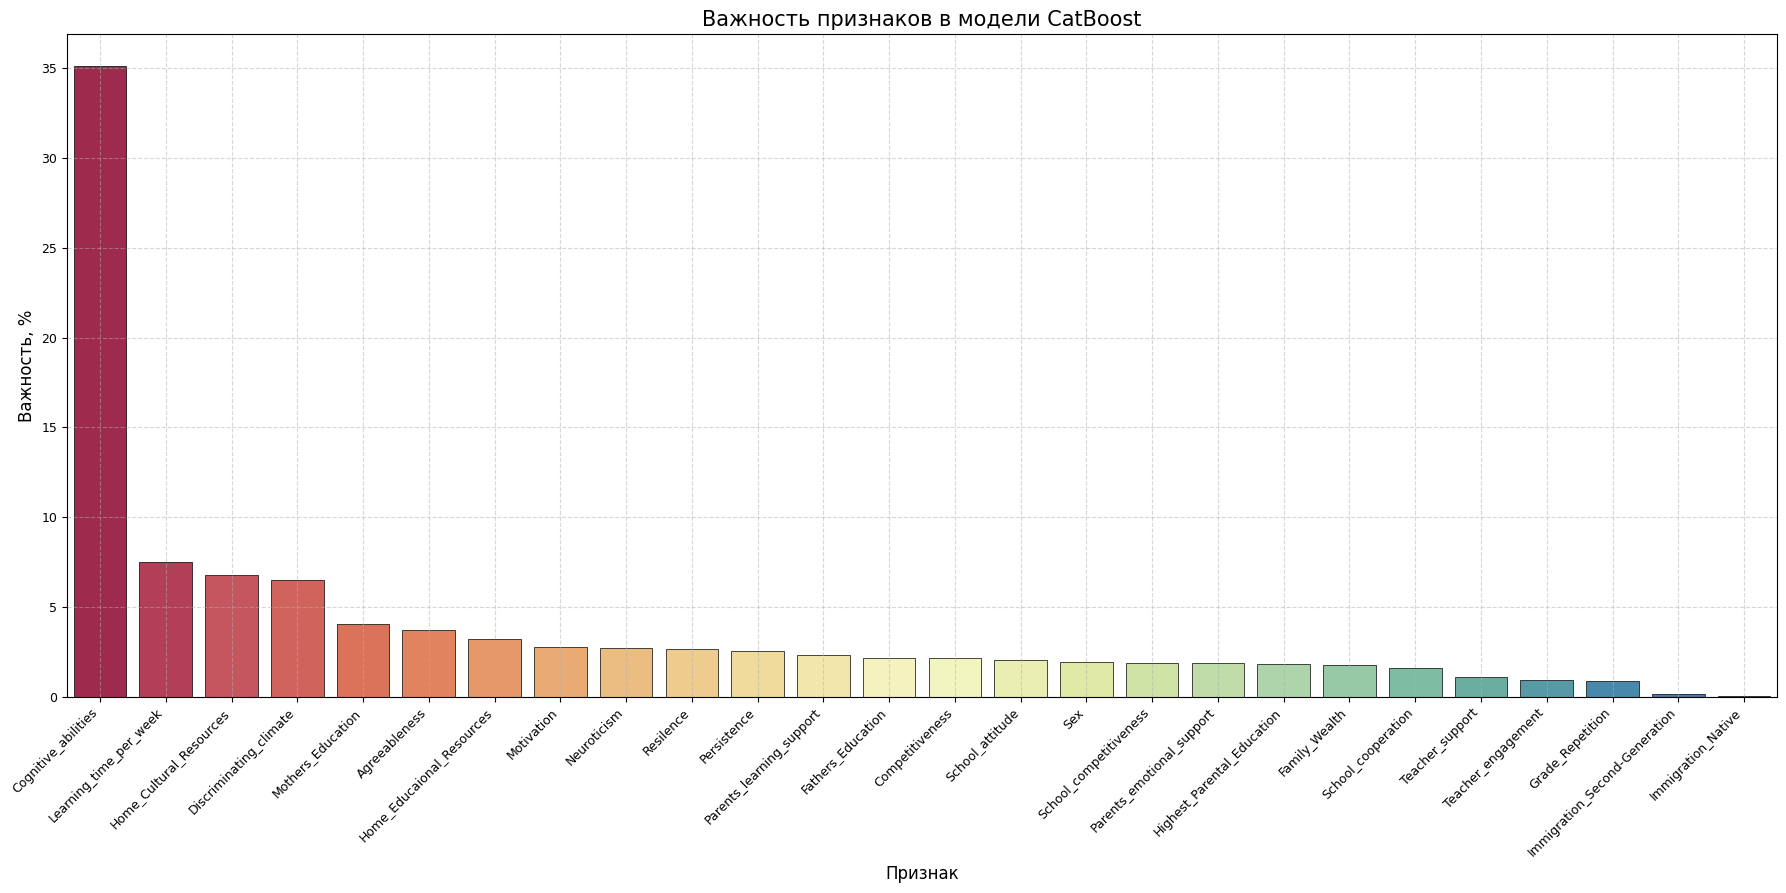

In [97]:
feature_importance = cb_v3.feature_importances_
features = X_train_full.columns

importance_table = pd.DataFrame({'Feature': features, 'Importance': feature_importance,
                                 'Importance_percent': 100 * abs(feature_importance) / np.sum(abs(feature_importance))})

importance_table = importance_table.sort_values('Importance_percent', ascending=False)

plt.figure(figsize=(18, 9))
sns.barplot(x='Feature', y='Importance_percent', data=importance_table, palette='Spectral', edgecolor='black', linewidth=0.5)

plt.title('Важность признаков в модели CatBoost', fontsize=15)
plt.xlabel('Признак', fontsize=12)
plt.ylabel('Важность, %', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [98]:
print("Важность признаков в модели:")
importance_table.reset_index(drop=True)

Важность признаков в модели:


,Feature,Importance,Importance_percent
0,Сognitive_abilities,35.138355,35.138355
1,Learning_time_per_week,7.489147,7.489147
2,Home_Cultural_Resources,6.772519,6.772519
3,Discriminating_climate,6.510709,6.510709
4,Mothers_Education,4.032410,4.032410
5,Agreeableness,3.706099,3.706099
6,Home_Educaional_Resources,3.205261,3.205261
7,Motivation,2.777153,2.777153
8,Neuroticism,2.696337,2.696337
9,Resilence,2.651074,2.651074


### 2.1.8. Применение метода SHAP, как одного из XAI-методов, для опеределения важности признаков и интерпретации индивидуального прогноза регрессионной прогностической модели

Для оценки того, какие факторы в целом оказывают наибольшее влияние на прогноз модели, на основании SHAP-значений мной был построен график глобальной значимости признаков, отражающий усреднённый вклад в прогноз каждого признака. Для расчета SHAP-значений для графика использовались величины, рассчитанные на основании среднего абсолютного значения SHAP на тестовой выборке, а в качестве прогностической модели - модель CatBoostRegressor с оптимальными гиперпараметрами. Использование именно тестовой выборки было обсуловлено необходимостью получения более строгой, объективной и практически значимой интерпретацию модели, ориентированной на её реальную применимость.

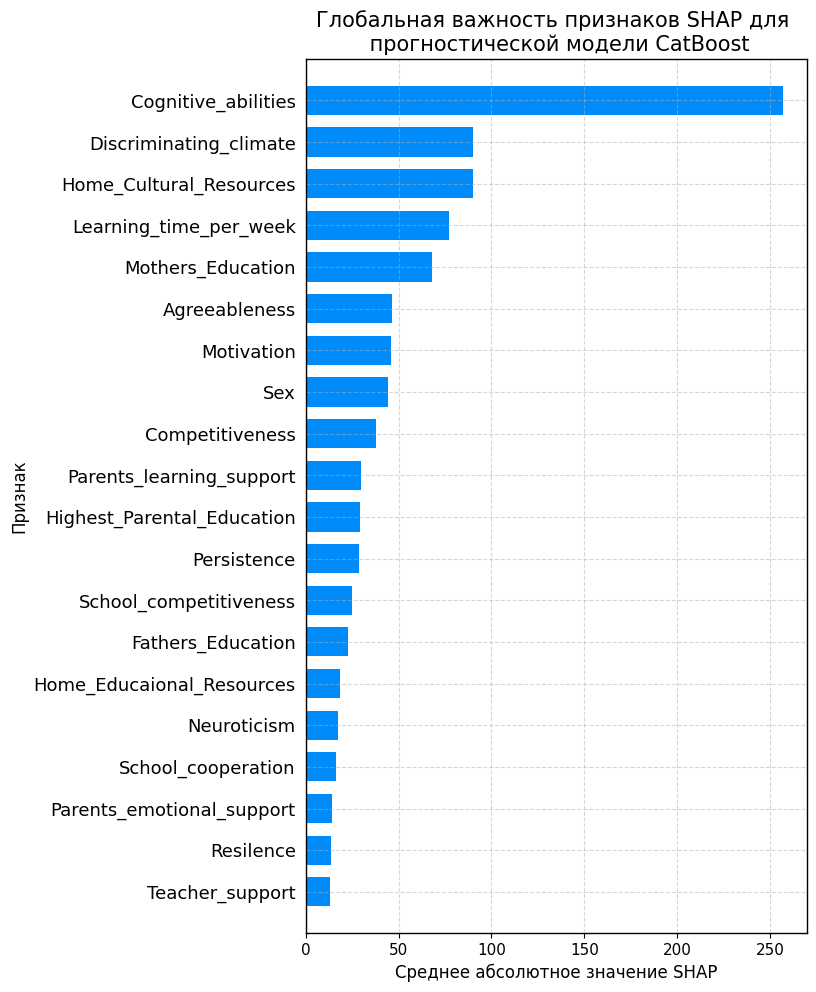

In [80]:
best_model = cb_v3

explainer_shap = shap.TreeExplainer(best_model)

X_test_sample = X_test_full
shap_values = explainer_shap.shap_values(X_test_sample)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title('Глобальная важность признаков SHAP для \n прогностической модели CatBoost', fontsize=15)
plt.xlabel('Среднее абсолютное значение SHAP', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.tick_params(axis='both', colors='black')
plt.grid(linestyle='--', alpha=0.5)
for spine in ['top', 'bottom', 'left', 'right']:
    plt.gca().spines[spine].set_visible(True)
    plt.gca().spines[spine].set_color('black')
    plt.gca().spines[spine].set_linewidth(1)
#plt.tight_layout()
plt.show()

На основании построенного графика можно сделать вывод, что наибольшее влияние на предсказание результативности оказывает признак, отражащюий когнитивные способности ученика: его вклад значительно превышает вклад остальных переменных. Это вполне логичный результат, поскольку уровень интеллекта отражает способность учащихся обрабатывать информацию и эффективно использовать приобретенные знания на практике, что отражается на академических достижениях. Вторым по значимости для прогноза является индикатор дискриминационной среды, что подтверждает тезисы научных предшественников о влиятельности характеристики школьной среды на образовательные успехи учащихся. Доступность культурных ресурсов и время, уделяемое обучению, находятся на строчках ниже, однако тем не менее оказываются важными при предсказании.
Также полученные результаты сигнализируют о том, что вклад личностных характеристик при прогнозировании учебных результатов имеют наивысший прогностический характер, в отличие от остальных социально-экономических и средовых факторов, демонстрирующих меньшую влиятельность.

Мы рассмотрели, какие из признаков вносят наиболее важный вклад в предсказание лучшей прогностической регрессионной модели, поэтому теперь перейдем к рассмотрению индивидуальных предсказаний школьников и объяснению причин получения именно такого прогноза. Для того, чтобы понять, как именно модель машинного обучения пришла к своему предсказанию, построим визуализацию формата "Waterfall plot". В качестве базового значения для графика используется среднее предсказание по всей выборке, от которого затем каждый признак либо отнимает, либо прибавляет определённое количество баллов. Красные полосы означают положительный вклад признака, а синие - отрицательный. Итогом последовательного добавления или вычитания вкладов всех признаков становится финальное предсказание модели для данного ученика.

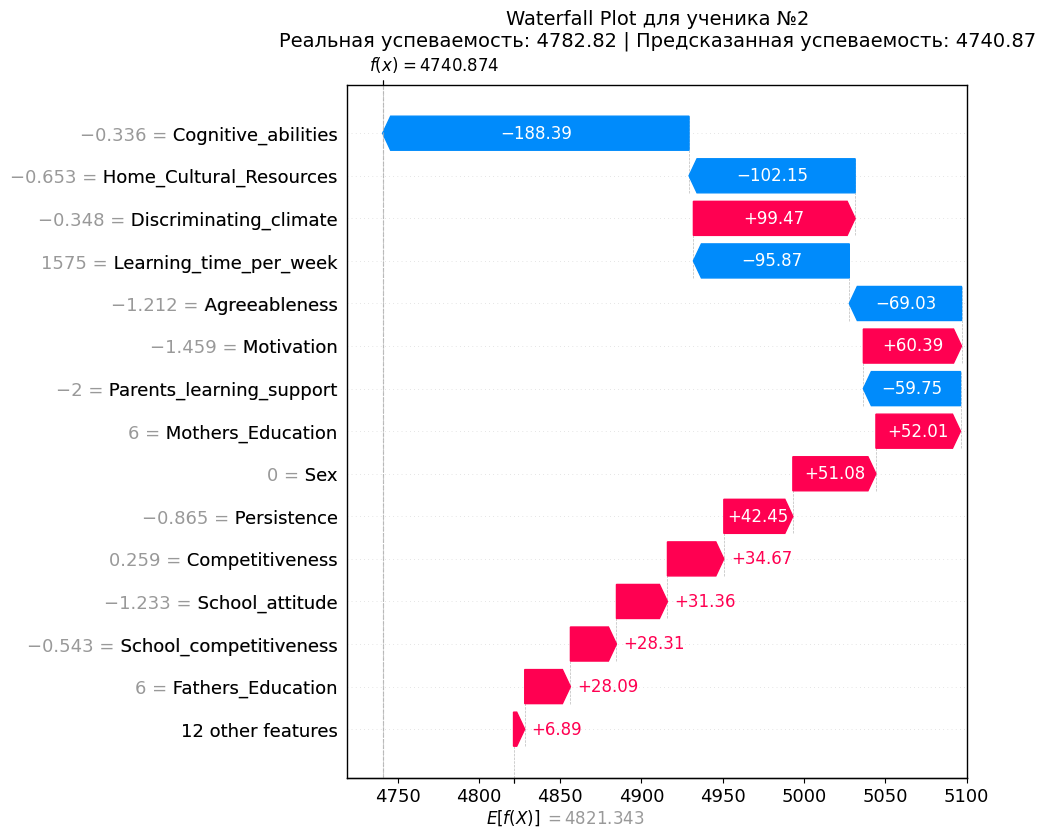

In [79]:
idx = 2
observation = X_test_sample.iloc[idx:idx+1]
true_grade = y_test_reg.iloc[idx]
predicted_grade = best_model.predict(observation)[0]

plt.figure(figsize=(14, 9))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer_shap.expected_value,
        data=observation.values[0],
        feature_names=X_test_sample.columns.tolist()
    ),
    show=False,
    max_display=15
)
plt.title(f'Waterfall Plot для ученика №{idx}\nРеальная успеваемость: {true_grade:.2f} | Предсказанная успеваемость: {predicted_grade:.2f}', fontsize=14)
plt.tick_params(axis='both', colors='black')
for spine in ['top', 'bottom', 'left', 'right']:
    plt.gca().spines[spine].set_visible(True)
    plt.gca().spines[spine].set_color('black')
    plt.gca().spines[spine].set_linewidth(1)
plt.grid(linestyle='--', alpha=0.5)
#plt.tight_layout()
plt.show()

Для ученика под номером 2 модель предсказала результат на уровне 4741 балла, тогда как реальная успеваемость составила 4783 балла: ошибка прогноза оказалась небольшой и составила около 42 баллов.

В качестве базового (среднего) предсказания по всей выборке использовался показатель в 4821 балл. Когнитивные способности школьника оказались ниже среднего, что отняло от потенциальной оценки почти 188 баллов. Низкая доступность домашних культурных ресурсов тоже оказала негативное влияние на балл, что снизило предсказание ещё на 102 балла. Значение времени, уделяемого учебе, эквивалентное 26 часам, оказалось меньше оптимального по выборке, вследствие чего этот показатель тоже отнял 96 баллов. Низкая доброжелательность и слабая поддержка со стороны родителей также внесли свой вклад в снижение, убрав 69 и 60 баллов соответственно. При этом некоторые факторы помогли ученику компенсировать потери: в их число вошли низкий дискриминационный климат и низкая конкуренция в школе, высокий уровень образования матери и отца, мужской пол, а также высокая любовь к конкуренции, в сумме добавившие около 200 баллов, позволив итоговому предсказанию остаться достаточно близким к реальной успеваемости.

Отдельно стоить отметить вклад таких признаков, как мотивация, настойчивость и посещение школы. Подобные значения тоже нормальны, несмотря на их трудное логическое объяснение, поскольку SHAP учитывает не изолированный вклад признака, а его взаимодействие с другими характеристиками ученика. Так, связь между психологическими чертами и успеваемостью не всегда линейна: чрезмерно высокая мотивация иногда связана с тревожностью и выгоранием, поэтому умеренно низкие значения в некоторых контекстах могут быть вполне объяснимыми.

## 2.2. Построение классификационных моделей для идентификации школьников в группе академического риска

## 2.2.1. Реализация и оценка качества модели LogisticRegression

Модель логистической регрессии использовалась в качестве базовой для задачи выявления обучающихся в группе академического риска. Для получения репрезентативных оценок при построении данной модели были учтены веса респондентов-школьников и асимметрия классов. Результаты этой модели используются как бенчмарк, с которым сравниваются остальные более продвинутые классификационные модели.

In [ ]:
logr = LogisticRegression(random_state=42, max_iter=1000)
logr.fit(X_train_lin, y_train_cl, sample_weight=w_train)


y_pred_train_logr = logr.predict(X_train_lin)
y_pred_test_logr = logr.predict(X_test_lin)
y_pred_train_logr_pr = logr.predict_proba(X_train_lin)[:, 1]
y_pred_test_logr_pr = logr.predict_proba(X_test_lin)[:, 1]

print("Метрики качества модели на обучающей выборке:")
print(classification_report(y_train_cl, y_pred_train_logr, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на обучающей выборке: {roc_auc_score(y_train_cl, y_pred_train_logr_pr):.4f}")
print()
print("Метрики качества модели на тестовой выборке:")
print(classification_report(y_test_cl, y_pred_test_logr, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на тестовой выборке: {roc_auc_score(y_test_cl, y_pred_test_logr_pr):.4f}")

Метрики качества модели на обучающей выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       0.82      0.97      0.89      9319
Риск присутствует (1)       0.54      0.14      0.22      2364

             accuracy                           0.80     11683
            macro avg       0.68      0.55      0.55     11683
         weighted avg       0.76      0.80      0.75     11683

ROC-AUC на обучающей выборке: 0.7631
Метрики качества модели на тестовой выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       0.82      0.97      0.89      2330
Риск присутствует (1)       0.60      0.17      0.27       591

             accuracy                           0.81      2921
            macro avg       0.71      0.57      0.58      2921
         weighted avg       0.78      0.81      0.76      2921

ROC-AUC на тестовой выборке: 0.7642


In [ ]:
logr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced',)
logr.fit(X_train_lin, y_train_cl, sample_weight=w_train)


y_pred_train_logr = logr.predict(X_train_lin)
y_pred_test_logr = logr.predict(X_test_lin)
y_pred_train_logr_pr = logr.predict_proba(X_train_lin)[:, 1]
y_pred_test_logr_pr = logr.predict_proba(X_test_lin)[:, 1]

print("Метрики качества модели на обучающей выборке:")
print(classification_report(y_train_cl, y_pred_train_logr, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на обучающей выборке: {roc_auc_score(y_train_cl, y_pred_train_logr_pr):.4f}")
print()
print("Метрики качества модели на тестовой выборке:")
print(classification_report(y_test_cl, y_pred_test_logr, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на тестовой выборке: {roc_auc_score(y_test_cl, y_pred_test_logr_pr):.4f}")

Метрики качества модели на обучающей выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       0.89      0.73      0.80      9319
Риск присутствует (1)       0.37      0.64      0.47      2364

             accuracy                           0.71     11683
            macro avg       0.63      0.68      0.64     11683
         weighted avg       0.78      0.71      0.73     11683

ROC-AUC на обучающей выборке: 0.7648

Метрики качества модели на тестовой выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       0.89      0.73      0.80      2330
Риск присутствует (1)       0.37      0.64      0.47       591

             accuracy                           0.71      2921
            macro avg       0.63      0.68      0.64      2921
         weighted avg       0.78      0.71      0.73      2921

ROC-AUC на тестовой выборке: 0.7647


При прогнозировании модель логистической регрессии продемонстрировала идентичные значения метрик на обучающей и тестовой выборках: полнота ($Recall$) составила 0.64, точность ($Precision$) – 0.37, а $F1-Score$ – 0.47. Значение $ROC-AUC Score$ на обеих выборках зафиксировалось на уровне 0.76. Полученные результаты свидетельствуют об отсутствии переобучения, что характерно для линейных моделей, однако также указывают на ограниченную способность модели разделять классы: при приемлемой чувствительности к классу риска модель демонстрирует высокий уровень ложноположительных срабатываний, что является ожидаемым базовым уровнем для линейного подхода.

## 2.2.2. Реализация и оценка качества модели LogisticRegression + Regularization

С целью повышения обобщающей способности и борьбы с потенциальной мультиколлинеарностью, а также для снижения риска переобучения, была построена модель логистической регрессии с L1- и L2-регуляризацией. Оптимизация гиперпараметров осуществлялась по метрике полноты (Recall) с использованием механизма GridSearchCV. Так, для построения модели в качестве оптимальных гиперпараметров были определены C = 10.0 и penalty =  'L1'.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

lr_tuned = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

grid_lr = GridSearchCV(
    lr_tuned,
    param_grid_lr,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)
grid_lr.fit(X_train_lin, y_train_cl, sample_weight=w_train)

print(f"Лучшие параметры: {grid_lr.best_params_}")

y_pred_train_logrt = grid_lr.predict(X_train_lin)
y_pred_test_logrt = grid_lr.predict(X_test_lin)
y_pred_train_logr_pr = grid_lr.predict_proba(X_train_lin)[:, 1]
y_pred_test_logr_pr = grid_lr.predict_proba(X_test_lin)[:, 1]


print("Метрики качества модели на обучающей выборке:")
print(classification_report(y_train_cl, y_pred_train_logrt, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на обучающей выборке: {roc_auc_score(y_train_cl, y_pred_train_logr_pr):.4f}")
print()
print("Метрики качества модели на тестовой выборке:")
print(classification_report(y_test_cl, y_pred_test_logrt, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на тестовой выборке: {roc_auc_score(y_test_cl, y_pred_test_logr_pr):.4f}")

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Лучшие параметры: {'C': 10.0, 'penalty': 'l1', 'solver': 'saga'}
Метрики качества модели на обучающей выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       0.90      0.58      0.71      9319
Риск присутствует (1)       0.31      0.74      0.44      2364

             accuracy                           0.62     11683
            macro avg       0.61      0.66      0.57     11683
         weighted avg       0.78      0.62      0.65     11683

ROC-AUC на обучающей выборке: 0.7096

Метрики качества модели на тестовой выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       0.89      0.58      0.71      2330
Риск присутствует (1)       0.31      0.72      0.43       591

             accuracy                           0.61      2921
            macro avg       0.60      0.65      0.57      2921
         weighted avg       0.77      0.61    

Внедрение регуляризации и настройка гиперпараметров позволили повысить чувствительность модели к целевому классу академического риска: полнота ($Recall$) на обучающей выборке составила 0.74, на тестовой – 0.72. Это означает, что модель стала лучше выявлять школьников, действительно входящих в группу риска, что является приоритетной задачей в контексте раннего обнаружения потенциально неуспевающих учеников. Однако наблюдаемое улучшение достигнуто за счет снижения точности ($Precision$), значение которой составило 0.31 на обеих выборках. Иными словами, повышение чувствительности модели к классу академического риска привело к более частой ошибочной классификация преуспевающих школьников как «академически неуспешных. В результате итоговый F1-Score незначительно снизился по сравнению с базовой моделью: до 0.44 на обучающей и 0.43 на тестовой выборках.
Значение $ROC-AUC Score$ также продемонстрировало снижение – до 0.70 на обеих выборках, что подтверждает ухудшение общей разделяющей способности модели. Этот эффект является классическим проявлением компромисса между полнотой и точностью: в условиях несбалансированного распределения классов повышение чувствительности к миноритарному классу почти неизбежно сопровождается снижением точности прогноза.


## 2.2.3. Реализация и оценка качества модели Decision Tree

В качестве первой нелинейной модели было построено взвешенное дерево решений (Decision Tree), учитывающее веса школьников в выборке. На этапе обучения была предпринята попытка настройки гиперпараметров с использованием механизма RandomizedSearchCV с 5-кратной перекрестной проверкой. Выбор случайного поиска вместо полного перебора сетки был обусловлен необходимостью сокращения вычислительных затрат при сохранении приемлемого качества подбора. Оптимизация осуществлялась по метрике полноты ($Recall$), что было обусловлено приоритетом выявления максимального числа учащихся, входящих в группу академического риска.

In [ ]:
dt_cl = DecisionTreeClassifier(random_state=42)
dt_cl.fit(X_train_full, y_train_cl, sample_weight=w_train)

y_pred_train_dt_cl = dt_cl.predict(X_train_full)
y_pred_test_dt_cl = dt_cl.predict(X_test_full)
y_pred_train_dt_pr = dt_cl.predict_proba(X_train_full)[:, 1]
y_pred_test_dt_pr = dt_cl.predict_proba(X_test_full)[:, 1]

print("Метрики качества модели на обучающей выборке:")
print(classification_report(y_train_cl, y_pred_train_dt_cl, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на обучающей выборке: {roc_auc_score(y_train_cl, y_pred_train_dt_pr):.4f}")
print()
print("Метрики качества модели на тестовой выборке:")
print(classification_report(y_test_cl, y_pred_test_dt_pr, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на тестовой выборке: {roc_auc_score(y_test_cl, y_pred_test_dt_pr):.4f}")

Метрики качества модели на обучающей выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       1.00      1.00      1.00      9319
Риск присутствует (1)       1.00      1.00      1.00      2364

             accuracy                           1.00     11683
            macro avg       1.00      1.00      1.00     11683
         weighted avg       1.00      1.00      1.00     11683

ROC-AUC на обучающей выборке: 1.0000

Метрики качества модели на тестовой выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       0.84      0.82      0.83      2330
Риск присутствует (1)       0.36      0.39      0.37       591

             accuracy                           0.74      2921
            macro avg       0.60      0.61      0.60      2921
         weighted avg       0.74      0.74      0.74      2921

ROC-AUC на тестовой выборке: 0.6072


In [ ]:
param_grid_dt = {
    'max_depth': [5, 7, 10, 12],
    'min_samples_split': [50, 100, 150],
    'min_samples_leaf': [20, 50, 75, 100],
    'max_features': ['sqrt', 'log2', 0.5, 0.7],
    'class_weight': ['balanced']
}

dt_cl = DecisionTreeClassifier(random_state=42)

grid_dt = GridSearchCV(
    dt_cl,
    param_grid_dt,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)
grid_dt.fit(X_train_full, y_train_cl, sample_weight=w_train)
dt_best = grid_dt.best_estimator_

print(f"Лучшие параметры: {grid_dt.best_params_}")

y_pred_train_dt_best = dt_best.predict(X_train_full)
y_pred_test_dt_best = dt_best.predict(X_test_full)
y_pred_train_dt_pr = dt_best.predict_proba(X_train_full)[:, 1]
y_pred_test_dt_pr = dt_best.predict_proba(X_test_full)[:, 1]

print("Метрики качества модели на обучающей выборке:")
print(classification_report(y_train_cl, y_pred_train_dt_best, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на обучающей выборке: {roc_auc_score(y_train_cl, y_pred_train_dt_pr):.4f}")
print()
print("Метрики качества модели на тестовой выборке:")
print(classification_report(y_test_cl, y_pred_test_dt_best, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на тестовой выборке: {roc_auc_score(y_test_cl, y_pred_test_dt_pr):.4f}")

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Метрики качества модели на обучающей выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       0.91      0.65      0.76      9319
Риск присутствует (1)       0.35      0.75      0.48      2364

             accuracy                           0.67     11683
            macro avg       0.63      0.70      0.62     11683
         weighted avg       0.80      0.67      0.70     11683

ROC-AUC на обучающей выборке: 0.7635

Метрики качества модели на тестовой выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       0.90      0.64      0.75      2330
Риск присутствует (1)       0.34      0.73      0.46       591

             accuracy                           0.65      2921
            macro avg       0.62      0.68      0.60      2921
         weighted avg       0.79      0.65      0.69      2921

ROC-AUC на тестовой выборке: 0.7418


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist_dt = {
    'max_depth': randint(5, 15),
    'min_samples_split': randint(50, 200),
    'min_samples_leaf': randint(20, 100),
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced',]
}

random_dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist_dt,
    n_iter=30,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_dt.fit(X_train_full, y_train_cl, sample_weight=w_train)
print(f"Лучшие параметры: {random_dt.best_params_}")

y_pred_train_dt_rand = random_dt.predict(X_train_full)
y_pred_test_dt_rand = random_dt.predict(X_test_full)
y_pred_train_dt_pr = random_dt.predict_proba(X_train_full)[:, 1]
y_pred_test_dt_pr = random_dt.predict_proba(X_test_full)[:, 1]

print("Метрики качества модели на обучающей выборке:")
print(classification_report(y_train_cl, y_pred_train_dt_rand, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на обучающей выборке: {roc_auc_score(y_train_cl, y_pred_train_dt_pr):.4f}")
print()
print("Метрики качества модели на тестовой выборке:")
print(classification_report(y_test_cl, y_pred_test_dt_rand, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на тестовой выборке: {roc_auc_score(y_test_cl, y_pred_test_dt_pr):.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 90, 'min_samples_split': 58}
Метрики качества модели на обучающей выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       0.93      0.57      0.71      9319
Риск присутствует (1)       0.33      0.82      0.47      2364

             accuracy                           0.62     11683
            macro avg       0.63      0.70      0.59     11683
         weighted avg       0.80      0.62      0.66     11683

ROC-AUC на обучающей выборке: 0.7620

Метрики качества модели на тестовой выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       0.92      0.56      0.69      2330
Риск присутствует (1)       0.31      0.80      0.45       591

             accuracy                           0.61      2921
            macro avg       0.62      

По итогам проведенного подбора, наилучшее качество модели показала версия со следующими гиперпараметрами: class_weight = 'balanced'; max_depth = 5; max_features = 'sqrt'; min_samples_leaf = 90; min_samples_split = 58. Лучшая версия модели указанного типа после настройки гиперпараметров продемонстрировала на тестовой выборке полноту ($Recall$), равную 0.80, точность ($Precision$), равную 0.31, и F1-Score, равный 0.45. Значение же $ROC-AUC Score$ составило 0.74.  

## 2.2.4. Реализация и оценка качества модели Random Forest

Для повышения стабильности прогнозов и снижения дисперсии, характерной для одиночных деревьев решений, была построена модель ансамблевого машинного обучения – случайный лес. В отличие от дерева решений, случайный лес агрегирует предсказания множества деревьев, что позволяет снизить риск переобучения и повысить обобщающую способность модели. Для поиска наилучших параметров модели использовался механизм RandomizedSearchCV с 3-кратной перекрестной проверкой. Выбор 3 фолдов, а не 5, был обоснован необходимостью ускорения вычислений при работе с ансамблем, состоящим из большого количества деревьев. Оптимизация проводилась по метрике полноты ($Recall$), что соответствует приоритетной задаче исследования.

In [ ]:
rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train_full, y_train_cl, sample_weight=w_train)

y_pred_train_rf_base = rf_base.predict(X_train_full)
y_pred_test_rf_base = rf_base.predict(X_test_full)
y_pred_train_rf_pr = rf_base.predict_proba(X_train_full)[:, 1]
y_pred_test_rf_pr = rf_base.predict_proba(X_test_full)[:, 1]

print("Метрики качества модели на обучающей выборке:")
print(classification_report(y_train_cl, y_pred_train_rf_base, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на обучающей выборке: {roc_auc_score(y_train_cl, y_pred_train_rf_pr):.4f}")
print()
print("Метрики качества модели на тестовой выборке:")
print(classification_report(y_test_cl, y_pred_test_rf_base, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на тестовой выборке: {roc_auc_score(y_test_cl, y_pred_test_rf_pr):.4f}")

Метрики качества модели на обучающей выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       1.00      1.00      1.00      9319
Риск присутствует (1)       1.00      1.00      1.00      2364

             accuracy                           1.00     11683
            macro avg       1.00      1.00      1.00     11683
         weighted avg       1.00      1.00      1.00     11683

ROC-AUC на обучающей выборке: 1.0000

Метрики качества модели на тестовой выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       0.83      0.98      0.89      2330
Риск присутствует (1)       0.66      0.18      0.29       591

             accuracy                           0.82      2921
            macro avg       0.74      0.58      0.59      2921
         weighted avg       0.79      0.82      0.77      2921

ROC-AUC на тестовой выборке: 0.8107


In [ ]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_balanced.fit(X_train_full, y_train_cl, sample_weight=w_train)

y_pred_train_rf_bal = rf_balanced.predict(X_train_full)
y_pred_test_rf_bal = rf_balanced.predict(X_test_full)
y_pred_train_rf_pr = rf_balanced.predict_proba(X_train_full)[:, 1]
y_pred_test_rf_pr = rf_balanced.predict_proba(X_test_full)[:, 1]

print("Метрики качества модели на обучающей выборке:")
print(classification_report(y_train_cl, y_pred_train_rf_bal, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на обучающей выборке: {roc_auc_score(y_train_cl, y_pred_train_rf_pr):.4f}")
print()
print("Метрики качества модели на тестовой выборке:")
print(classification_report(y_test_cl, y_pred_test_rf_bal, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на тестовой выборке: {roc_auc_score(y_test_cl, y_pred_test_rf_pr):.4f}")

Метрики качества модели на обучающей выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       1.00      1.00      1.00      9319
Риск присутствует (1)       1.00      1.00      1.00      2364

             accuracy                           1.00     11683
            macro avg       1.00      1.00      1.00     11683
         weighted avg       1.00      1.00      1.00     11683

ROC-AUC на обучающей выборке: 1.0000

Метрики качества модели на тестовой выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       0.82      0.98      0.89      2330
Риск присутствует (1)       0.64      0.15      0.24       591

             accuracy                           0.81      2921
            macro avg       0.73      0.56      0.56      2921
         weighted avg       0.78      0.81      0.76      2921

ROC-AUC на тестовой выборке: 0.8018


In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None]
}

rf_grid = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    rf_grid,
    param_grid,
    n_iter=30,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

random_search.fit(X_train_full, y_train_cl, sample_weight=w_train)

print(f"Лучшие параметры: {random_search.best_params_}")

rf_tuned = random_search.best_estimator_

y_pred_train_rf_tuned = rf_tuned.predict(X_train_full)
y_pred_test_rf_tuned = rf_tuned.predict(X_test_full)
y_pred_train_rf_pr = rf_tuned.predict_proba(X_train_full)[:, 1]
y_pred_test_rf_pr = rf_tuned.predict_proba(X_test_full)[:, 1]

print("Метрики качества модели на обучающей выборке:")
print(classification_report(y_train_cl, y_pred_train_rf_tuned, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на обучающей выборке: {roc_auc_score(y_train_cl, y_pred_train_rf_pr):.4f}")
print()
print("Метрики качества модели на тестовой выборке:")
print(classification_report(y_test_cl, y_pred_test_rf_tuned, target_names=['Риск отсуствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на тестовой выборке: {roc_auc_score(y_test_cl, y_pred_test_rf_pr):.4f}")

Лучшие параметры: {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}
Метрики качества модели на обучающей выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       0.92      0.87      0.90      9319
Риск присутствует (1)       0.59      0.71      0.65      2364

             accuracy                           0.84     11683
            macro avg       0.76      0.79      0.77     11683
         weighted avg       0.86      0.84      0.85     11683

ROC-AUC на обучающей выборке: 0.8869

Метрики качества модели на тестовой выборке:
                       precision    recall  f1-score   support

  Риск отсуствует (0)       0.88      0.84      0.86      2330
Риск присутствует (1)       0.47      0.56      0.51       591

             accuracy                           0.78      2921
            macro avg       0.67      0.70      0.68      2921
         weighted avg       0.80      0.78  

In [ ]:
y_pred_train_rf_pr = rf_tuned.predict_proba(X_train_full)[:, 1]
y_pred_test_rf_pr = rf_tuned.predict_proba(X_test_full)[:, 1]

selected_threshold = 0.45
y_pred_train_rf_cal = (y_pred_train_rf_pr >= selected_threshold).astype(int)
y_pred_test_rf_cal = (y_pred_test_rf_pr >= selected_threshold).astype(int)

print("Метрики качества модели на обучающей выборке:")
print(classification_report(y_train_cl, y_pred_train_rf_cal, target_names=['Риск отсутствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на обучающей выборке: {roc_auc_score(y_train_cl, y_pred_train_rf_pr):.4f}")
print()
print("Метрики качества модели на тестовой выборке:")
print(classification_report(y_test_cl, y_pred_test_rf_cal, target_names=['Риск отсутствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на тестовой выборке: {roc_auc_score(y_test_cl, y_pred_test_rf_pr):.4f}")

Метрики качества модели на обучающей выборке:
                       precision    recall  f1-score   support

 Риск отсутствует (0)       0.94      0.81      0.87      9319
Риск присутствует (1)       0.51      0.79      0.62      2364

             accuracy                           0.81     11683
            macro avg       0.73      0.80      0.75     11683
         weighted avg       0.85      0.81      0.82     11683

ROC-AUC на обучающей выборке: 0.8869

Метрики качества модели на тестовой выборке:
                       precision    recall  f1-score   support

 Риск отсутствует (0)       0.90      0.77      0.83      2330
Риск присутствует (1)       0.43      0.67      0.52       591

             accuracy                           0.75      2921
            macro avg       0.66      0.72      0.68      2921
         weighted avg       0.81      0.75      0.77      2921

ROC-AUC на тестовой выборке: 0.7993


Наилучшей комбинацией гиперпараметров оказалась следующая: n_estimators = 200; min_samples_split = 20; min_samples_leaf = 4; max_features = 'log2'; max_depth = 10. Дополнительно было снижено пороговое вероятностное значение с 0.5 до 0.45 для наиболее полного охвата школьников, входящих в группу академического риска. Значения $ROC-AUC Score$ для лучшей модели зафиксировались на уровне 0.88 на обучающей выборке и 0.80 на тестовой. Разница между метриками на обучении и тесте составляет 0.08, что указывает на наличие умеренного переобучения. Особого внимания заслуживает показатель точности ($Precision$), который на тестовой выборке составил 0.43. Наблюдаемое повышение метрики в сравнении с предыдущими моделями достигнуто за счет снижения полноты: модель стала реже ошибаться, но при этом стала хуже выявлять реальные случаи риска.

## 2.2.5. Реализация и оценка качества модели XGBoost

Для дальнейшего повышения прогностической мощности была построена модель градиентного бустинга XGBoost. Настройка гиперпараметров также производилась с помощью уже упомянутого RandomizedSearchCV.

In [ ]:
xgb_base = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_base.fit(X_train_full, y_train_cl, sample_weight=w_train)

y_pred_train_xgb = xgb_base.predict(X_train_full)
y_pred_test_xgb = xgb_base.predict(X_test_full)
y_pred_train_xgb_pr = xgb_base.predict_proba(X_train_full)[:, 1]
y_pred_test_xgb_pr = xgb_base.predict_proba(X_test_full)[:, 1]

print("Метрики качества модели на обучающей выборке:")
print(classification_report(y_train_cl, y_pred_train_xgb, target_names=['Риск отсутствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на обучающей выборке: {roc_auc_score(y_train_cl, y_pred_train_xgb_pr):.4f}")
print()
print("Метрики качества модели на тестовой выборке:")
print(classification_report(y_test_cl, y_pred_test_xgb, target_names=['Риск отсутствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на тестовой выборке: {roc_auc_score(y_test_cl, y_pred_test_xgb_pr):.4f}")

Метрики качества модели на обучающей выборке:
                       precision    recall  f1-score   support

 Риск отсутствует (0)       0.94      0.98      0.96      9319
Риск присутствует (1)       0.92      0.74      0.82      2364

             accuracy                           0.93     11683
            macro avg       0.93      0.86      0.89     11683
         weighted avg       0.93      0.93      0.93     11683

ROC-AUC на обучающей выборке: 0.9660

Метрики качества модели на тестовой выборке:
                       precision    recall  f1-score   support

 Риск отсутствует (0)       0.84      0.93      0.88      2330
Риск присутствует (1)       0.53      0.31      0.39       591

             accuracy                           0.80      2921
            macro avg       0.69      0.62      0.64      2921
         weighted avg       0.78      0.80      0.78      2921

ROC-AUC на тестовой выборке: 0.7870


In [ ]:
ratio = len(y_train_cl[y_train_cl==0]) / len(y_train_cl[y_train_cl==1])
ratio

3.942470389170897

In [ ]:
xgb_weighted = xgb.XGBClassifier(
    n_estimators=100,
    scale_pos_weight=3.9,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_weighted.fit(X_train_full, y_train_cl, sample_weight=w_train)

y_pred_train_xgb_w = xgb_weighted.predict(X_train_full)
y_pred_test_xgb_w = xgb_weighted.predict(X_test_full)
y_pred_train_xgb_pr = xgb_weighted.predict_proba(X_train_full)[:, 1]
y_pred_test_xgb_pr = xgb_weighted.predict_proba(X_test_full)[:, 1]

print("Метрики качества модели на обучающей выборке:")
print(classification_report(y_train_cl, y_pred_train_xgb_w, target_names=['Риск отсутствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на обучающей выборке: {roc_auc_score(y_train_cl, y_pred_train_xgb_pr):.4f}")
print()
print("Метрики качества модели на тестовой выборке:")
print(classification_report(y_test_cl, y_pred_test_xgb_w, target_names=['Риск отсутствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на тестовой выборке: {roc_auc_score(y_test_cl, y_pred_test_xgb_pr):.4f}")

Метрики качества модели на обучающей выборке:
                       precision    recall  f1-score   support

 Риск отсутствует (0)       0.96      0.95      0.95      9319
Риск присутствует (1)       0.80      0.85      0.83      2364

             accuracy                           0.93     11683
            macro avg       0.88      0.90      0.89     11683
         weighted avg       0.93      0.93      0.93     11683

ROC-AUC на обучающей выборке: 0.9668

Метрики качества модели на тестовой выборке:
                       precision    recall  f1-score   support

 Риск отсутствует (0)       0.87      0.87      0.87      2330
Риск присутствует (1)       0.48      0.47      0.47       591

             accuracy                           0.79      2921
            macro avg       0.67      0.67      0.67      2921
         weighted avg       0.79      0.79      0.79      2921

ROC-AUC на тестовой выборке: 0.7870


In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [3, 5, 7, 9]
}

xgb_tuned = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

random_search = RandomizedSearchCV(
    xgb_tuned,
    param_grid,
    n_iter=25,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

random_search.fit(X_train_full, y_train_cl, sample_weight=w_train)

print(f"Лучшие параметры: {random_search.best_params_}")

xgb_tuned_be = random_search.best_estimator_

y_pred_train_xgb_tun = xgb_tuned_be.predict(X_train_full)
y_pred_test_xgb_tun = xgb_tuned_be.predict(X_test_full)
y_pred_train_xgb_pr = xgb_tuned_be.predict_proba(X_train_full)[:, 1]
y_pred_test_xgb_pr = xgb_tuned_be.predict_proba(X_test_full)[:, 1]

print("Метрики качества модели на обучающей выборке:")
print(classification_report(y_train_cl, y_pred_train_xgb_tun, target_names=['Риск отсутствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на обучающей выборке: {roc_auc_score(y_train_cl, y_pred_train_xgb_pr):.4f}")
print()
print("Метрики качества модели на тестовой выборке:")
print(classification_report(y_test_cl, y_pred_test_xgb_tun, target_names=['Риск отсутствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на тестовой выборке: {roc_auc_score(y_test_cl, y_pred_test_xgb_pr):.4f}")

Лучшие параметры: {'subsample': 0.9, 'scale_pos_weight': 5, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Метрики качества модели на обучающей выборке:
                       precision    recall  f1-score   support

 Риск отсутствует (0)       0.94      0.74      0.83      9319
Риск присутствует (1)       0.44      0.81      0.57      2364

             accuracy                           0.76     11683
            macro avg       0.69      0.78      0.70     11683
         weighted avg       0.84      0.76      0.78     11683

ROC-AUC на обучающей выборке: 0.8685

Метрики качества модели на тестовой выборке:
                       precision    recall  f1-score   support

 Риск отсутствует (0)       0.92      0.73      0.81      2330
Риск присутствует (1)       0.41      0.74      0.52       591

             accuracy                           0.73      2921
            macro avg       0.66      0.73      0.67      2921
         weighted avg       

Лучшей комбинацией для выбранного типа модели стали гиперпараметры: subsample = 0.9, scale_pos_weight = 5, n_estimators = 100, max_depth = 5, learning_rate = 0.05, colsample_bytree = 0.9. Настройка гиперпараметров градиентного бустинга и применение механизмов регуляризации позволили усилить восприимчивость модели к целевой категории академического риска: полнота ($Recall$) на обучающей выборке зафиксирована на уровне 0.81, на тестовой – 0.74. Данный результат свидетельствует о повышении эффективности идентификации школьников, действительно относящихся к группе риска, что выступает ключевой задачей в контексте раннего обнаружения потенциально неуспевающих обучающихся. Вместе с тем, указанное улучшение сопровождается снижением точности ($Precision$), составившим 0.44 на обучающей и 0.41 на тестовой выборках. Иными словами, рост чувствительности алгоритма к классу риска сопровождается более частым ошибочным отнесением благополучных учащихся в категорию риска. Вследствие этого показатель $F1-Score$ ожидаемо оказался сдержанным: 0.57 на обучающей выборке и 0.52 – на тестовой. Значение $ROC-AUC Score$ продемонстрировало высокие и стабильные результаты: 0.87 на обучающей выборке и 0.81 – на тестовой. Небольшой разрыв между выборками в 0.06 свидетельствует о хорошей обобщающей способности модели и отсутствии выраженного переобучения.

## 2.2.6. Реализация и оценка качества модели LightGBM

В качестве финальной, наиболее производительной модели был выбран LightGBM – модификация градиентного бустинга, оптимизированная для работы с большими данными и весами наблюдений. Гиперпараметры модели были подобраны вручную с учетом регуляризации для достижения сбалансированного результата.

In [20]:
lgb_params = {
    'n_estimators': 100,
    'max_depth': 7,
    'learning_rate': 0.04,
    'num_leaves': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.3,
    'scale_pos_weight': 4,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'verbose': -1
}

lgb_clf = lgb.LGBMClassifier(**lgb_params)
lgb_clf.fit(X_train_full, y_train_cl, sample_weight=w_train)

y_pred_train_lgb = lgb_clf.predict(X_train_full)
y_pred_test_lgb = lgb_clf.predict(X_test_full)
y_pred_train_lgb_pr = lgb_clf.predict_proba(X_train_full)[:, 1]
y_pred_test_lgb_pr = lgb_clf.predict_proba(X_test_full)[:, 1]

print("Метрики качества модели на обучающей выборке:")
print(classification_report(y_train_cl, y_pred_train_lgb, target_names=['Риск отсутствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на обучающей выборке: {roc_auc_score(y_train_cl, y_pred_train_lgb_pr):.4f}")
print()
print("Метрики качества модели на тестовой выборке:")
print(classification_report(y_test_cl, y_pred_test_lgb, target_names=['Риск отсутствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на тестовой выборке: {roc_auc_score(y_test_cl, y_pred_test_lgb_pr):.4f}")

Метрики качества модели на обучающей выборке:
                       precision    recall  f1-score   support

 Риск отсутствует (0)       0.92      0.75      0.83      9319
Риск присутствует (1)       0.43      0.73      0.54      2364

             accuracy                           0.75     11683
            macro avg       0.67      0.74      0.68     11683
         weighted avg       0.82      0.75      0.77     11683

ROC-AUC на обучающей выборке: 0.8284

Метрики качества модели на тестовой выборке:
                       precision    recall  f1-score   support

 Риск отсутствует (0)       0.92      0.75      0.83      2330
Риск присутствует (1)       0.43      0.73      0.54       591

             accuracy                           0.75      2921
            macro avg       0.67      0.74      0.68      2921
         weighted avg       0.82      0.75      0.77      2921

ROC-AUC на тестовой выборке: 0.8113


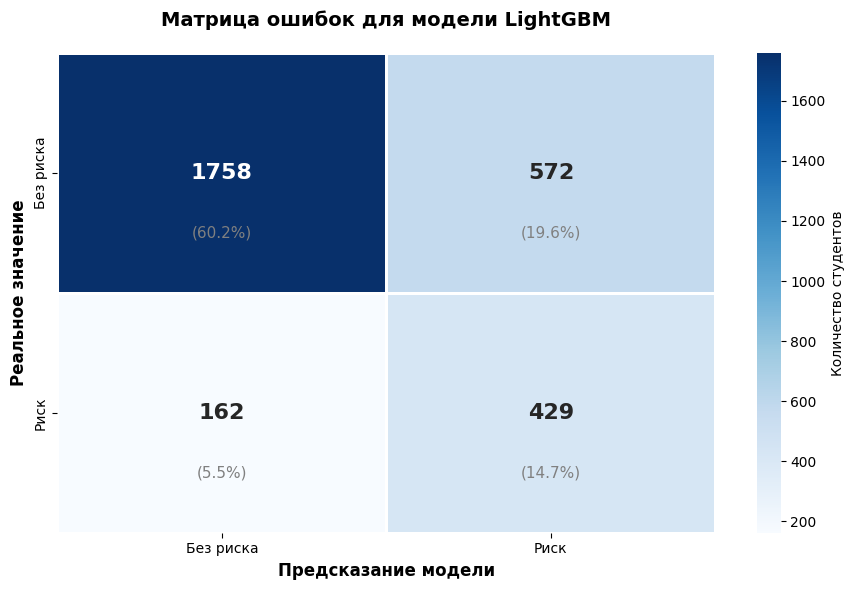

In [21]:
y_pred_xgb_tuned = lgb_clf.predict(X_test_full)
cm = confusion_matrix(y_test_cl, y_pred_xgb_tuned)

fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Без риска', 'Риск'],
            yticklabels=['Без риска', 'Риск'],
            ax=ax,
            annot_kws={'size': 16, 'weight': 'bold'},
            cbar_kws={'label': 'Количество студентов', 'shrink': 1},
            linewidths=1,
            linecolor='white')
total = np.sum(cm)
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        ax.text(j+0.5, i+0.75, f'({pct:.1f}%)',
                ha='center', va='center', fontsize=11, color='gray')
ax.set_title('Матрица ошибок для модели LightGBM',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Предсказание модели', fontsize=12, fontweight='bold')
ax.set_ylabel('Реальное значение', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Матрица ошибок наглядно демонстрирует, что модель LightGBM обладает хорошей чувствительностью к целевому классу, что является приоритетной задачей в контексте раннего выявления академического риска. Вместе с тем, модель демонстрирует относительно высокий уровень ложноположительных срабатываний, что приводит к невысокой точности. Полученные результаты свидетельствуют о том, что модель LightGBM является эффективным инструментом для скрининга и выявления группы академического риска, однако требует дополнительной валидации ложноположительных срабатываний перед принятием окончательных решений о включении учащихся в программы поддержки.

In [ ]:
lgb_params = {
    'n_estimators': 100,
    'max_depth': 7,
    'random_state': 42,
}

lgb_clf = lgb.LGBMClassifier(**lgb_params)
lgb_clf.fit(X_train_full, y_train_cl, sample_weight=w_train)

y_pred_train_lgb = lgb_clf.predict(X_train_full)
y_pred_test_lgb = lgb_clf.predict(X_test_full)
y_pred_train_lgb_pr = lgb_clf.predict_proba(X_train_full)[:, 1]
y_pred_test_lgb_pr = lgb_clf.predict_proba(X_test_full)[:, 1]

print("Метрики качества модели на обучающей выборке:")
print(classification_report(y_train_cl, y_pred_train_lgb, target_names=['Риск отсутствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на обучающей выборке: {roc_auc_score(y_train_cl, y_pred_train_lgb_pr):.4f}")
print()
print("Метрики качества модели на тестовой выборке:")
print(classification_report(y_test_cl, y_pred_test_lgb, target_names=['Риск отсутствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на тестовой выборке: {roc_auc_score(y_test_cl, y_pred_test_lgb_pr):.4f}")

Метрики качества модели на обучающей выборке:
                       precision    recall  f1-score   support

 Риск отсутствует (0)       0.88      0.97      0.92      9319
Риск присутствует (1)       0.81      0.46      0.59      2364

             accuracy                           0.87     11683
            macro avg       0.84      0.72      0.76     11683
         weighted avg       0.86      0.87      0.86     11683

ROC-AUC на обучающей выборке: 0.8991

Метрики качества модели на тестовой выборке:
                       precision    recall  f1-score   support

 Риск отсутствует (0)       0.84      0.95      0.89      2330
Риск присутствует (1)       0.61      0.30      0.41       591

             accuracy                           0.82      2921
            macro avg       0.73      0.63      0.65      2921
         weighted avg       0.80      0.82      0.80      2921

ROC-AUC на тестовой выборке: 0.8094


In [ ]:
y_pred_train_lgb_pr = lgb_clf.predict_proba(X_train_full)[:, 1]
y_pred_test_lgb_pr = lgb_clf.predict_proba(X_test_full)[:, 1]

selected_threshold = 0.48
y_pred_train_lgb = (y_pred_train_lgb_pr >= selected_threshold).astype(int)
y_pred_test_lgb = (y_pred_test_lgb_pr >= selected_threshold).astype(int)

print("Метрики качества модели на обучающей выборке:")
print(classification_report(y_train_cl, y_pred_train_lgb, target_names=['Риск отсутствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на обучающей выборке: {roc_auc_score(y_train_cl, y_pred_train_lgb_pr):.4f}")
print()
print("Метрики качества модели на тестовой выборке:")
print(classification_report(y_test_cl, y_pred_test_lgb, target_names=['Риск отсутствует (0)', 'Риск присутствует (1)']))
print(f"ROC-AUC на тестовой выборке: {roc_auc_score(y_test_cl, y_pred_test_lgb_pr):.4f}")

Метрики качества модели на обучающей выборке:
                       precision    recall  f1-score   support

 Риск отсутствует (0)       0.88      0.97      0.92      9319
Риск присутствует (1)       0.80      0.49      0.61      2364

             accuracy                           0.87     11683
            macro avg       0.84      0.73      0.77     11683
         weighted avg       0.87      0.87      0.86     11683

ROC-AUC на обучающей выборке: 0.8991

Метрики качества модели на тестовой выборке:
                       precision    recall  f1-score   support

 Риск отсутствует (0)       0.85      0.94      0.89      2330
Риск присутствует (1)       0.59      0.32      0.42       591

             accuracy                           0.82      2921
            macro avg       0.72      0.63      0.65      2921
         weighted avg       0.79      0.82      0.80      2921

ROC-AUC на тестовой выборке: 0.8094


Полнота ($Recall$) на обучающей и тестовой выборках составила 0.73 и 0.73 соответственно, точность ($Precision$) – 0.43 и 0.43, а $F1-Score$ – 0.54 и 0.54. Полное совпадение метрик на обеих выборках свидетельствует об отсутствии переобучения и высокой обобщающей способности алгоритма. Значение $ROC-AUC Score$ продемонстрировало устойчивые результаты: 0.83 на обучающей выборке и 0.81 на тестовой. Незначительный разрыв между метриками для выборок дополнительно подтверждает стабильность модели и её пригодность для работы с новыми данными.

Ключевое отличие LightGBM от предыдущих алгоритмов заключается в гармоничном балансе между полнотой и точностью. В отличие от XGBoost, где приоритет был отдан чувствительности к классу риска ($Recall$ = 0.74 и $Precision$ = 0.41), LightGBM демонстрирует более сбалансированные показатели ($Recall$ = 0.73 и $Precision$ = 0.43). Это означает, что модель не только эффективно выявляет школьников, действительно входящих в группу академического риска, но и минимизирует число ложноположительных срабатываний. Достигнутая согласованность метрик указывает на оптимальный баланс между чувствительностью к целевому классу и точностью прогноза, что делает LightGBM наиболее предпочтительным алгоритмом среди всех рассмотренных моделей для решения задачи выявления школьников группы академического риска.


### 2.2.7. Применение метода SHAP, как одного из XAI-методов, для опеределения важности признаков и интерпретации индивидуального прогноза классификационной прогностической модели

Для осуществления оценки важности признаков при построении прогноза моделью, на основании SHAP-значений мной был построен график глобальной значимости факторов, отражающий усреднённый вклад в прогноз каждого признака. Для расчета SHAP-значений для графика использовались величины, рассчитанные на основании среднего абсолютного значения SHAP на тестовой выборке, а в качестве прогностической модели использовалась лучшая классификационная прогностическая модель - LightGBM с оптимальными гиперпараметрами. Выбор тестовой выборки для расчёта SHAP-значений обусловлен необходимостью обеспечения объективности и практической значимости интерпретации. В отличие от анализа на обучающей выборке, который может отражать специфические шумы и особенности конкретных наблюдений, оценка на тестовых данных позволяет получить более реалистичное представление о применимости модели к новым данным.

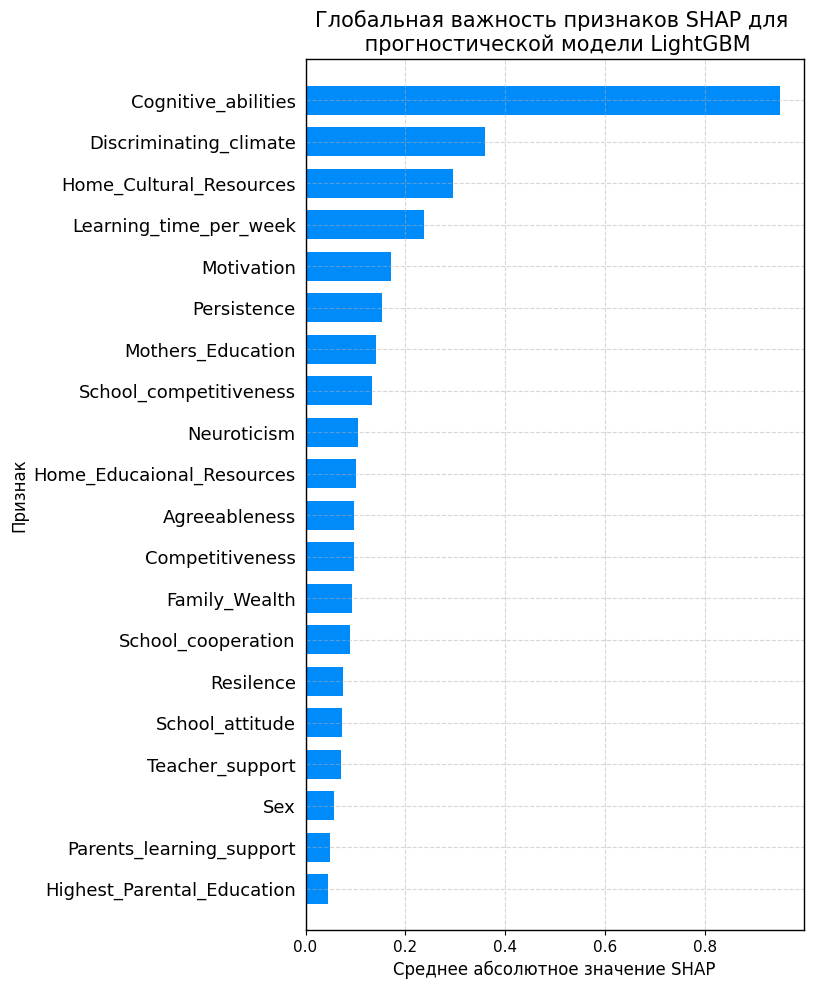

In [ ]:
best_model = lgb_clf

explainer_shap = shap.TreeExplainer(best_model)

X_test_sample = X_test_full
shap_values = explainer_shap.shap_values(X_test_sample)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title('Глобальная важность признаков SHAP для \n прогностической модели LightGBM', fontsize=15)
plt.xlabel('Среднее абсолютное значение SHAP', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.tick_params(axis='both', colors='black')
plt.grid(linestyle='--', alpha=0.5)
for spine in ['top', 'bottom', 'left', 'right']:
    plt.gca().spines[spine].set_visible(True)
    plt.gca().spines[spine].set_color('black')
    plt.gca().spines[spine].set_linewidth(1)
#plt.tight_layout()
plt.show()

На основании построенного графика можно сделать вывод, что наибольшее влияние на предсказание академического риска оказывает признак, отражающий когнитивные способности ученика: его среднее абсолютное SHAP-значение, составляющие больше 0.9 у.ед. значительно превышает вклад остальных переменных. Вторым по значимости фактором выступает дискриминационный климат с оценкой вклада около 0.38 у.ед.. Наличие дискриминации по любым признакам создаёт дополнительное психологическое давление и снижает учебную мотивацию, повышая вероятность попадания в группу риска. Третью и четвёртую позиции занимают доступность домашних культурных ресурсов и время, уделяемое обучению. Эти результаты согласуются с исследованиями PISA, показывающими, что культурный капитал семьи и учебная дисциплина являются важными, хотя и не доминирующими, предикторами академических достижений. Особого внимания заслуживает тот факт, что личностные характеристики - мотивация, настойчивость, нейротизм, доброжелательность и жизнестойкость - в совокупности демонстрируют высокую прогностическую ценность, сопоставимую с социально-экономическими и средовыми факторами. Это указывает на то, что психологические особенности учащихся играют немаловажную роль в формировании прогнозов относительно академического перфоманса школьника.

Мы рассмотрели, какие из признаков вносят наиболее важный вклад в предсказание лучшей прогностической классификационной модели LightGBM, поэтому теперь перейдем к рассмотрению индивидуальных идентификаций обучающихся и объяснению причин получения именно такого прогноза. Для достижения поставленной задачи построим визуализацию формата "Waterfall plot". В качестве базового значения для графика используется среднее предсказание вероятности попадания в группу академического риска по всей выборке, от которого затем каждый признак либо отнимает, либо прибавляет определённую долю вероятности попадания. Красные полосы означают рост вероятности занесения респондента в группу риска, а синие - снижение. Итогом последовательного добавления или вычитания долей вероятности по всем признакам становится финальное вероятностное значение, на основании которого модель принимает решение о необходимости добавлении рассматриваемого ученика в группу академического риска.

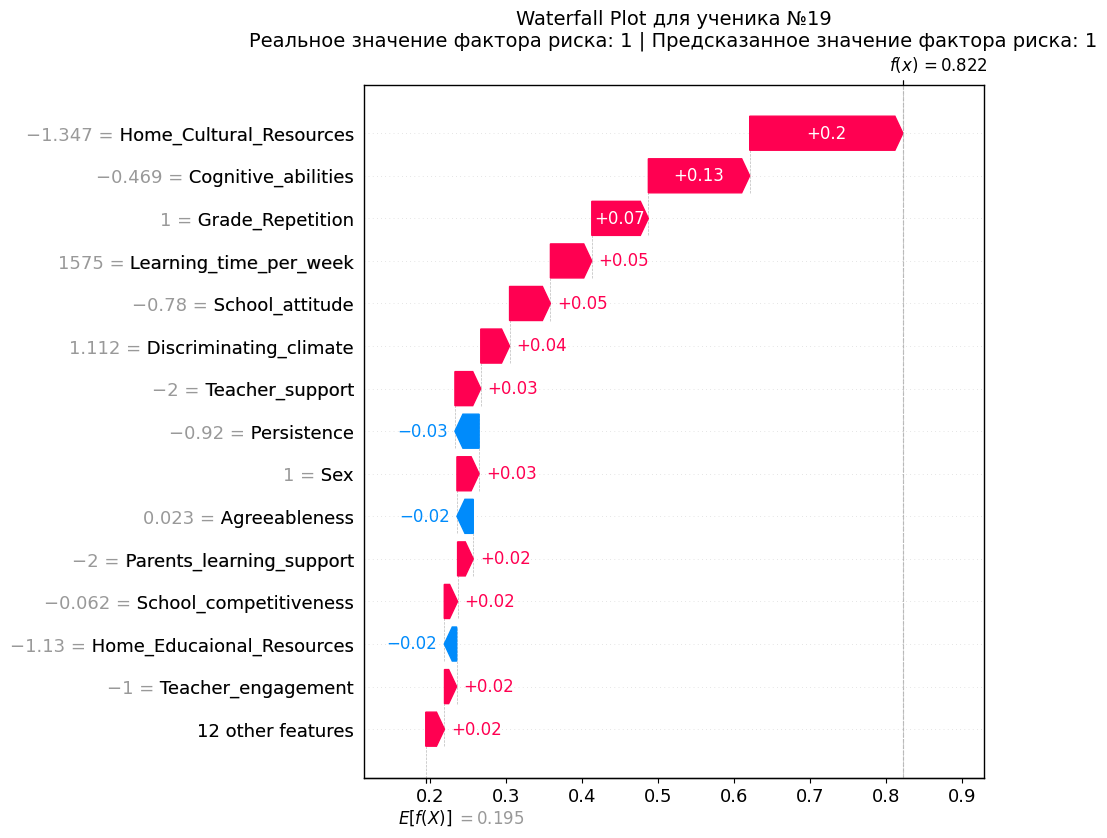

In [ ]:
idx = 19
observation = X_test_sample.iloc[idx:idx+1]
true_risk = y_test_cl.iloc[idx]
predicted_proba = best_model.predict_proba(observation)[0][1]
predicted_risk = best_model.predict(observation)[0]

explainer_shap = shap.TreeExplainer(best_model, X_test_sample, feature_perturbation="interventional", model_output='probability')
shap_values = explainer_shap(observation)

plt.figure(figsize=(16, 9))
shap.waterfall_plot(
    shap_values[0],
    show=False,
    max_display=15
)
plt.title(f'Waterfall Plot для ученика №{idx}\nРеальное значение фактора риска: {true_risk:.0f} | Предсказанное значение фактора риска: {predicted_risk:.0f}', fontsize=14)
plt.tick_params(axis='both', colors='black')
for spine in ['top', 'bottom', 'left', 'right']:
    plt.gca().spines[spine].set_visible(True)
    plt.gca().spines[spine].set_color('black')
    plt.gca().spines[spine].set_linewidth(1)
plt.grid(linestyle='--', alpha=0.5)
plt.show()

Ученика под номером 19 модель занесла в категорию академического риска, тогда как как реальное значение фактора риска составило: вероятность риска по модели при этом составила 82.2%.

В качестве базового (среднего) предсказания по всей выборке использовался показатель f(x) = 0.195. Это означает, что в среднем по выборке вероятность попадания в группу академического риска составляет около 19.5%. Низкая доступность культурных ресурсов дома способствовала повышению вероятности попадания в группу академического риска на 0.2 у.ед, в то время как умственные способности, оцениваемые ниже уровня интеллекта среди всех российских школьников, повысили вероятность на 0.13 у.ед. Фактор повторения курса, равный 1, увеличил вероятность попадания в группу академического риска на 0.07 у.ед., а неоптимальное количество времени, уделяемого учебе, (~26,5 часов) - на 0.05 у. ед.. Средовые факторы - высокий дискриминационный климат в школе и отсутствие учительской поддержки - аналогично другим вышеупомянутым показателям стали сигналом для модели к занесению школьника в группу риска. В качестве показателей, снизивших вероятность присвоения ученику фактора риска, выступили низкая настойчивость и дружелюбность.

Как уже отмечалось в блоке с построением регрессионных моделей, SHAP учитывает не изолированный вклад признака, а его взаимодействие с другими характеристиками обучающегося, вследствие чего не все вклады характеристик могут быть истрактованы напрямую.
